<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Gaming_Hours_vs_Academic_%26_Work_Performance_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gaming Hours vs Academic & Work Performance

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

# About the dataset

This dataset, titled 'Gaming Hours vs Academic & Work Performance,' provides a comprehensive look into the relationship between gaming habits and academic or professional outcomes for 1000 individuals. Each entry captures various attributes including age, gender, occupation, preferred game type, daily and weekly gaming hours, primary gaming time, sleep hours, stress level, focus level, academic or work score, productivity level, and the overall performance impact attributed to gaming.

Our initial exploration revealed a clean dataset, free from missing values or duplicates, ensuring reliable analysis. Univariate analysis showed a diverse distribution across demographics, with a near-equal split between male and female participants, and slightly more students than working professionals. Gaming hours varied, with `Daily_Gaming_Hours` averaging around 3.3 hours and `Weekly_Gaming_Hours` around 23.2 hours. Academic and work scores, alongside productivity levels, generally clustered around the average of 75. Critically, the `Performance_Impact` column indicated that for a significant majority (76.2%), gaming had a neutral impact, while a smaller portion experienced negative (13.5%) or positive (10.3%) effects.

Bivariate analysis and the correlation matrix provided deeper insights. We observed a mild negative correlation between increased `Daily_Gaming_Hours` and `Academic_or_Work_Score`, suggesting that excessive gaming *might* be linked to slightly lower performance. Conversely, `Academic_or_Work_Score` and `Productivity_Level` showed a strong positive correlation, as expected. `Stress_Level` also seemed to increase with more gaming hours, while `Focus_Level` had a more complex relationship. Further investigation into these relationships will be crucial to understand the nuances of how gaming influences individual performance and well-being.

In [ ]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d prince7489/gaming-hours-vs-academic-and-work-performance

# Unziping the downloaded file
!unzip gaming-hours-vs-academic-and-work-performance.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/prince7489/gaming-hours-vs-academic-and-work-performance
License(s): CC0-1.0
  0% 0.00/15.0k [00:00<?, ?B/s]
100% 15.0k/15.0k [00:00<00:00, 54.0MB/s]
Archive:  gaming-hours-vs-academic-and-work-performance.zip
  inflating: Gaming_Hours_vs_Performance_1000_Rows.csv  


In [ ]:
df = pd.read_csv('Gaming_Hours_vs_Performance_1000_Rows.csv')
df.head(11)

,User_ID,Age,Gender,Occupation,Game_Type,Daily_Gaming_Hours,Weekly_Gaming_Hours,Primary_Gaming_Time,Sleep_Hours,Stress_Level,Focus_Level,Academic_or_Work_Score,Productivity_Level,Performance_Impact
0,U0001,21,Male,Working Professional,Action,4.0,28.0,Morning,4.6,6,4,69,66,Negative
1,U0002,35,Female,Student,Sports,1.0,7.0,Night,5.4,2,7,67,72,Neutral
2,U0003,26,Male,Student,Puzzle,2.0,14.0,Morning,8.0,4,8,82,82,Positive
3,U0004,32,Male,Working Professional,Action,1.0,7.0,Night,4.9,7,7,71,66,Neutral
4,U0005,19,Male,Working Professional,Action,2.1,14.7,Morning,7.0,7,7,67,63,Neutral
5,U0006,29,Female,Student,Casual,5.3,37.1,Evening,6.0,9,8,78,75,Neutral
6,U0007,35,Male,Student,Sports,4.4,30.8,Evening,7.2,3,7,95,92,Neutral
7,U0008,25,Male,Working Professional,Sports,2.0,14.0,Evening,8.2,5,8,75,70,Positive
8,U0009,32,Male,Working Professional,Strategy,0.9,6.3,Morning,8.2,7,4,86,87,Positive
9,U0010,25,Male,Working Professional,Action,4.6,32.2,Morning,6.7,8,7,80,80,Neutral


In [ ]:
df.tail(11)

,User_ID,Age,Gender,Occupation,Game_Type,Daily_Gaming_Hours,Weekly_Gaming_Hours,Primary_Gaming_Time,Sleep_Hours,Stress_Level,Focus_Level,Academic_or_Work_Score,Productivity_Level,Performance_Impact
989,U0990,31,Female,Student,Action,3.5,24.5,Morning,5.2,8,6,73,78,Neutral
990,U0991,35,Male,Working Professional,Simulation,1.0,7.0,Night,4.6,8,3,86,90,Neutral
991,U0992,35,Female,Student,Strategy,4.9,34.3,Evening,7.2,8,4,69,71,Neutral
992,U0993,29,Male,Working Professional,Puzzle,5.7,39.9,Night,5.9,9,6,80,75,Negative
993,U0994,31,Male,Student,Action,2.0,14.0,Morning,7.9,8,8,70,65,Positive
994,U0995,31,Male,Working Professional,Strategy,4.8,33.6,Night,7.9,7,5,65,69,Neutral
995,U0996,23,Female,Working Professional,Simulation,4.0,28.0,Morning,7.8,8,4,95,96,Neutral
996,U0997,30,Female,Student,Puzzle,2.9,20.3,Morning,4.9,4,7,62,67,Neutral
997,U0998,18,Male,Working Professional,Action,1.0,7.0,Night,4.6,2,8,92,89,Neutral
998,U0999,25,Female,Student,Simulation,4.5,31.5,Morning,8.4,7,4,70,75,Neutral


In [ ]:
df.shape

(1000, 14)

In [ ]:
df.columns

Index(['User_ID', 'Age', 'Gender', 'Occupation', 'Game_Type',
       'Daily_Gaming_Hours', 'Weekly_Gaming_Hours', 'Primary_Gaming_Time',
       'Sleep_Hours', 'Stress_Level', 'Focus_Level', 'Academic_or_Work_Score',
       'Productivity_Level', 'Performance_Impact'],
      dtype='object')

In [ ]:
df.dtypes

,0
User_ID,object
Age,int64
Gender,object
Occupation,object
Game_Type,object
Daily_Gaming_Hours,float64
Weekly_Gaming_Hours,float64
Primary_Gaming_Time,object
Sleep_Hours,float64
Stress_Level,int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   User_ID                 1000 non-null   object 
 1   Age                     1000 non-null   int64  
 2   Gender                  1000 non-null   object 
 3   Occupation              1000 non-null   object 
 4   Game_Type               1000 non-null   object 
 5   Daily_Gaming_Hours      1000 non-null   float64
 6   Weekly_Gaming_Hours     1000 non-null   float64
 7   Primary_Gaming_Time     1000 non-null   object 
 8   Sleep_Hours             1000 non-null   float64
 9   Stress_Level            1000 non-null   int64  
 10  Focus_Level             1000 non-null   int64  
 11  Academic_or_Work_Score  1000 non-null   int64  
 12  Productivity_Level      1000 non-null   int64  
 13  Performance_Impact      1000 non-null   object 
dtypes: float64(3), int64(5), object(6)
memory

In [ ]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
User_ID,1000,1000,U1000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1000.0,NaN,NaN,NaN,26.6,5.207218,18.0,22.0,27.0,31.0,35.0
Gender,1000,2,Female,513,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Occupation,1000,2,Student,524,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Game_Type,1000,6,Simulation,192,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Daily_Gaming_Hours,1000.0,NaN,NaN,NaN,3.3203,1.613059,0.5,2.0,3.3,4.8,6.0
Weekly_Gaming_Hours,1000.0,NaN,NaN,NaN,23.2421,11.291414,3.5,14.0,23.1,33.6,42.0
Primary_Gaming_Time,1000,3,Morning,341,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sleep_Hours,1000.0,NaN,NaN,NaN,6.4795,1.155848,4.5,5.475,6.5,7.5,8.5
Stress_Level,1000.0,NaN,NaN,NaN,5.454,2.281905,2.0,3.0,5.0,7.0,9.0


In [ ]:
df.isnull().sum()

,0
User_ID,0
Age,0
Gender,0
Occupation,0
Game_Type,0
Daily_Gaming_Hours,0
Weekly_Gaming_Hours,0
Primary_Gaming_Time,0
Sleep_Hours,0
Stress_Level,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

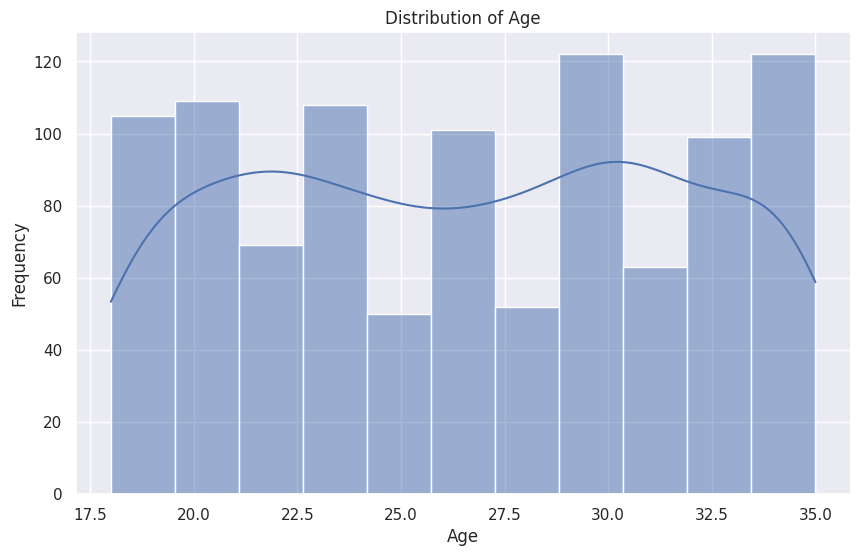

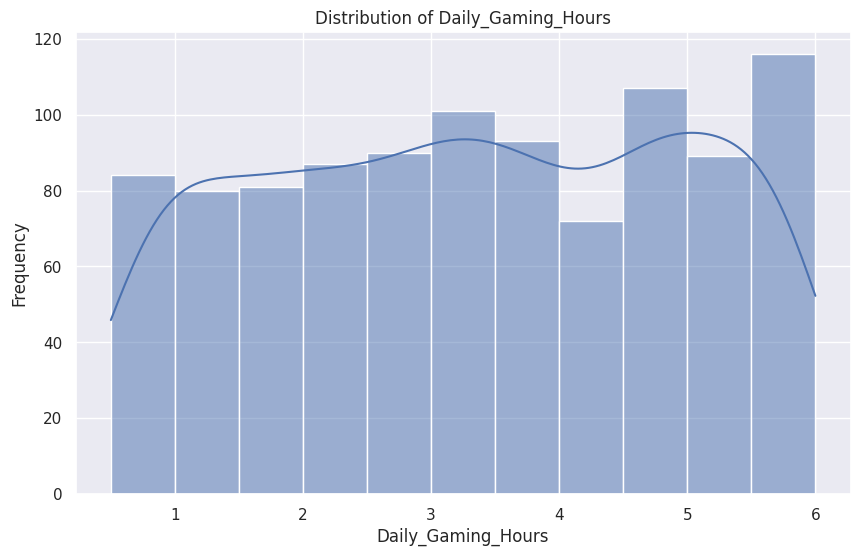

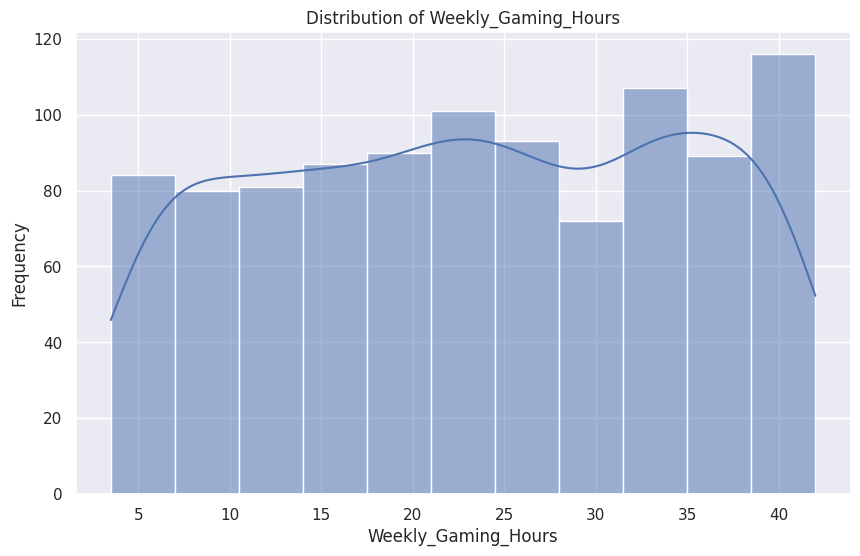

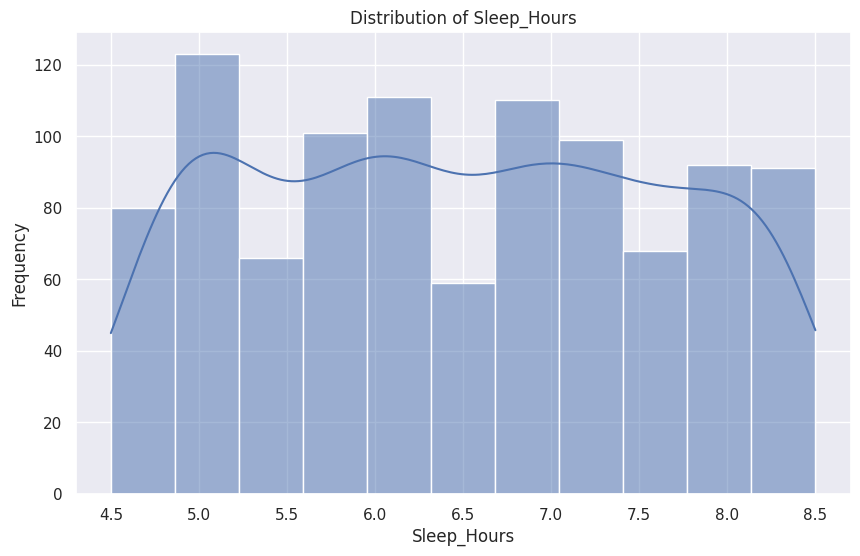

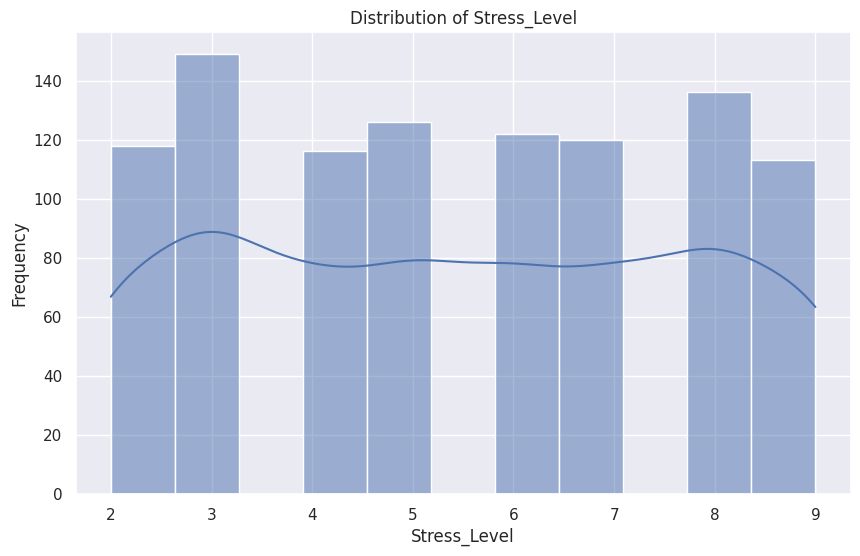

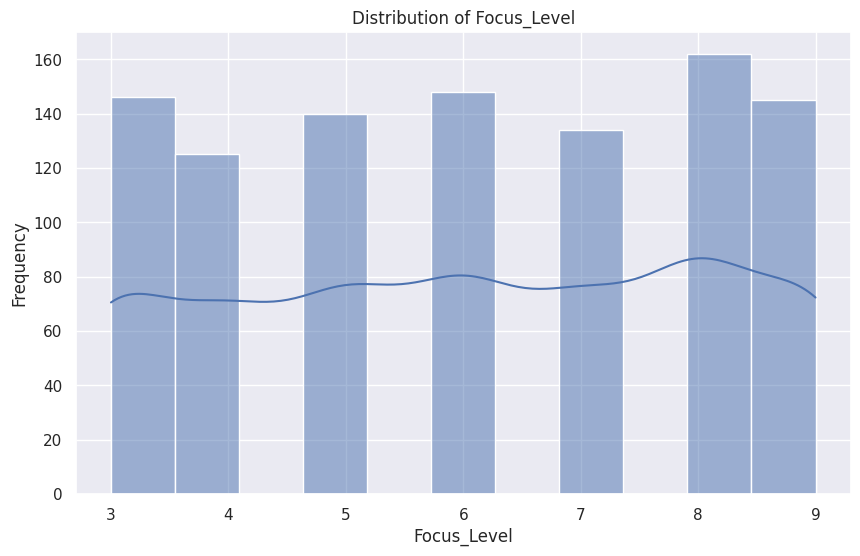

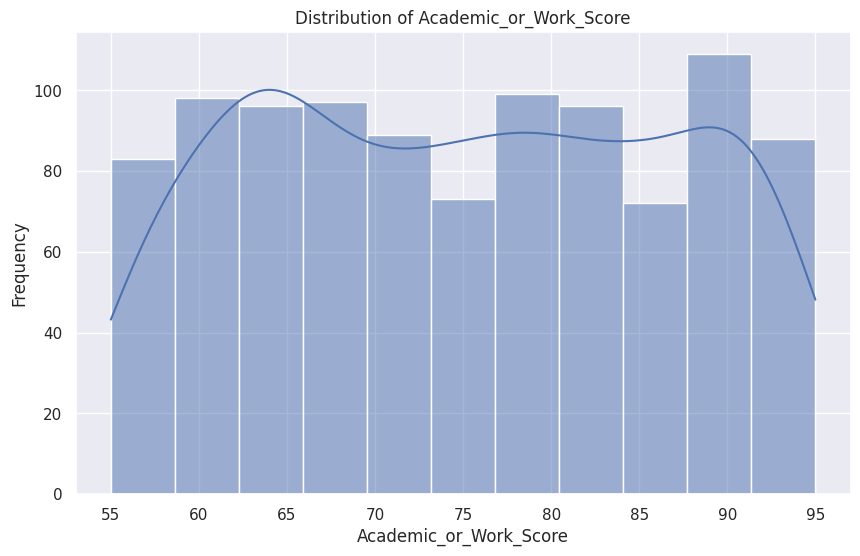

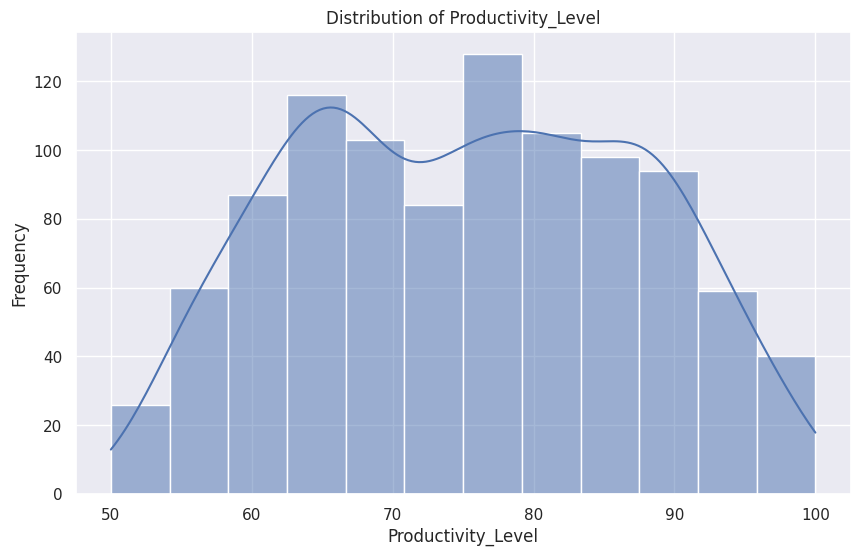

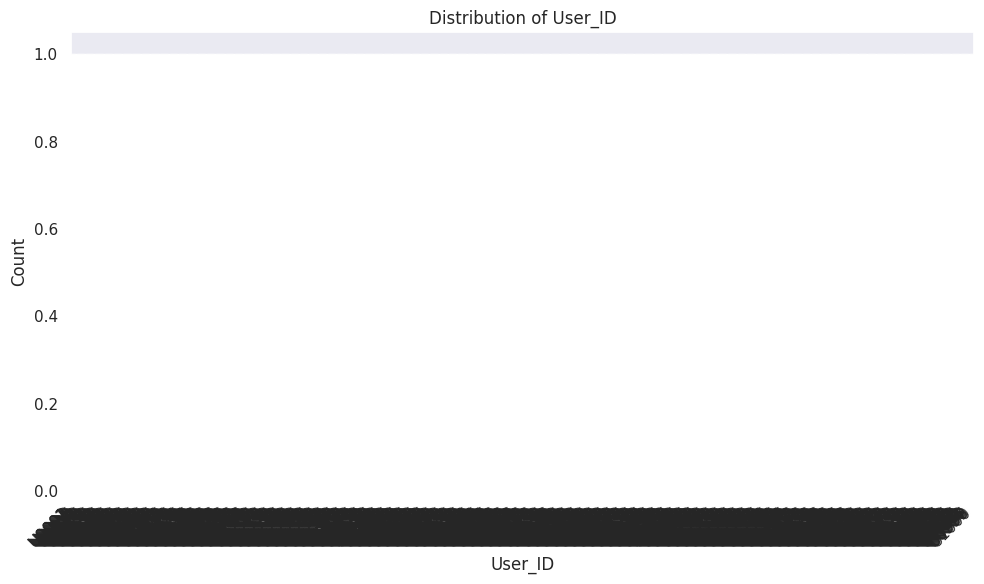

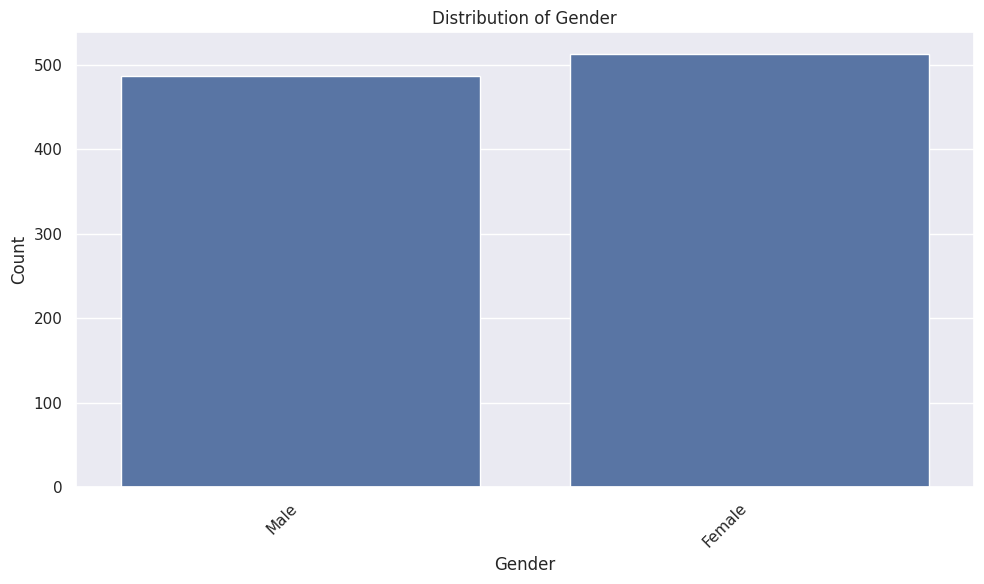

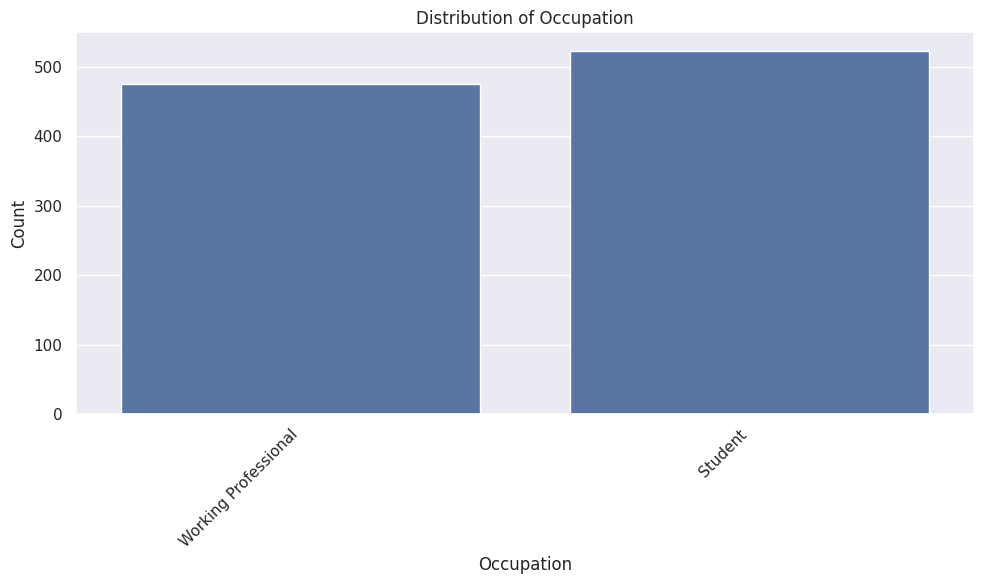

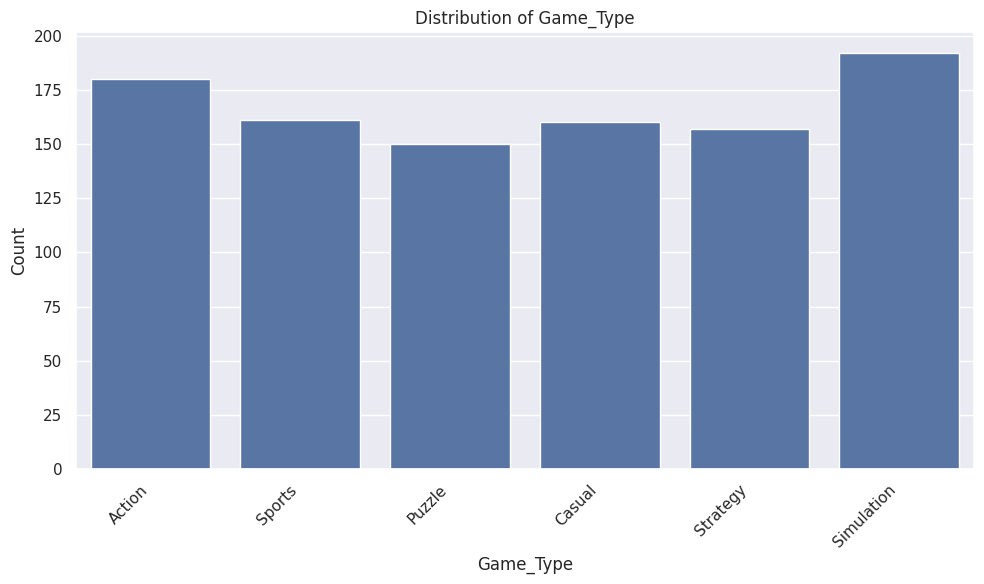

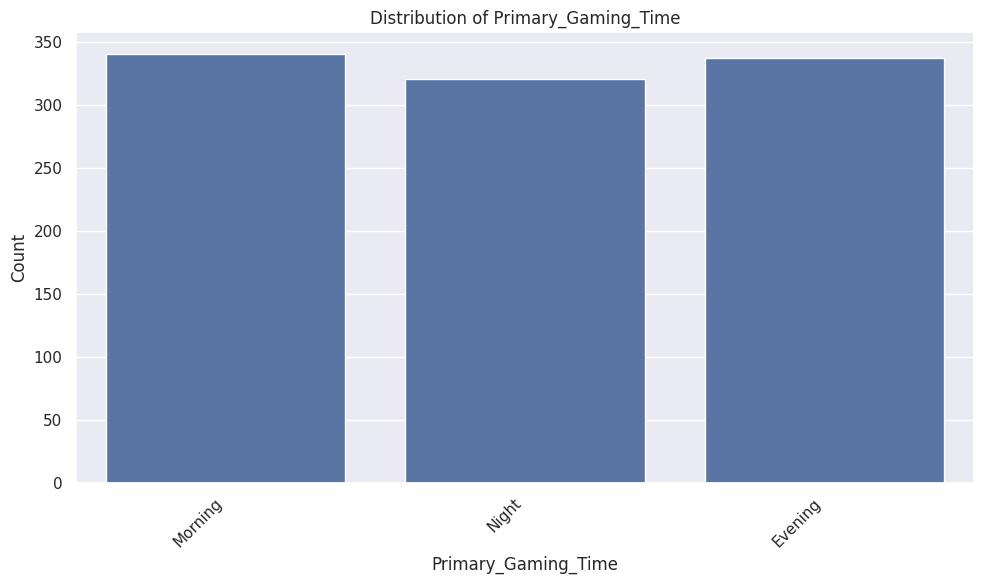

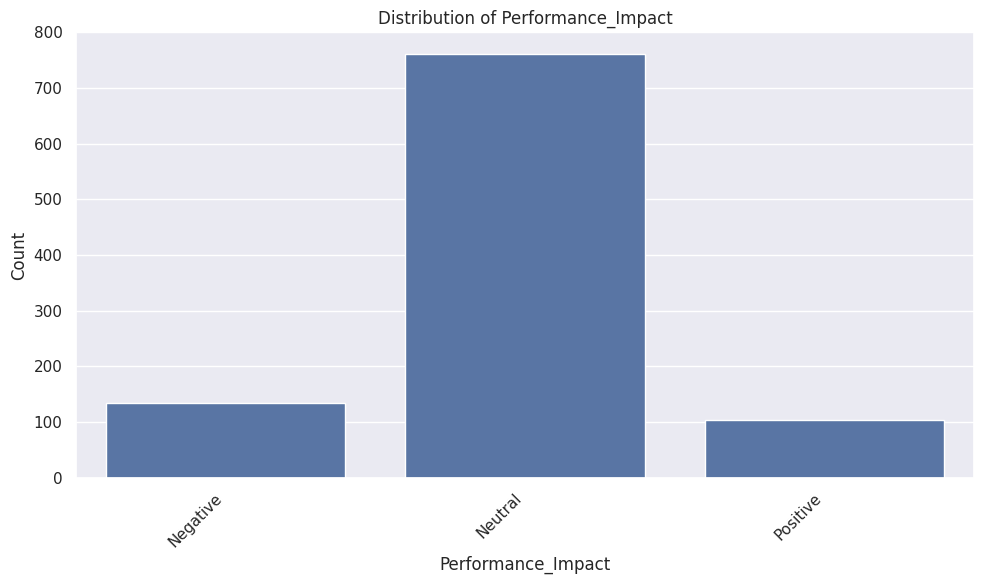

Value counts for User_ID:
User_ID
U1000    1
U0001    1
U0002    1
U0003    1
U0004    1
        ..
U0013    1
U0012    1
U0011    1
U0010    1
U0009    1
Name: count, Length: 1000, dtype: int64

Value counts for Gender:
Gender
Female    513
Male      487
Name: count, dtype: int64

Value counts for Occupation:
Occupation
Student                 524
Working Professional    476
Name: count, dtype: int64

Value counts for Game_Type:
Game_Type
Simulation    192
Action        180
Sports        161
Casual        160
Strategy      157
Puzzle        150
Name: count, dtype: int64

Value counts for Primary_Gaming_Time:
Primary_Gaming_Time
Morning    341
Evening    338
Night      321
Name: count, dtype: int64

Value counts for Performance_Impact:
Performance_Impact
Neutral     762
Negative    135
Positive    103
Name: count, dtype: int64



In [ ]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterating through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterating through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

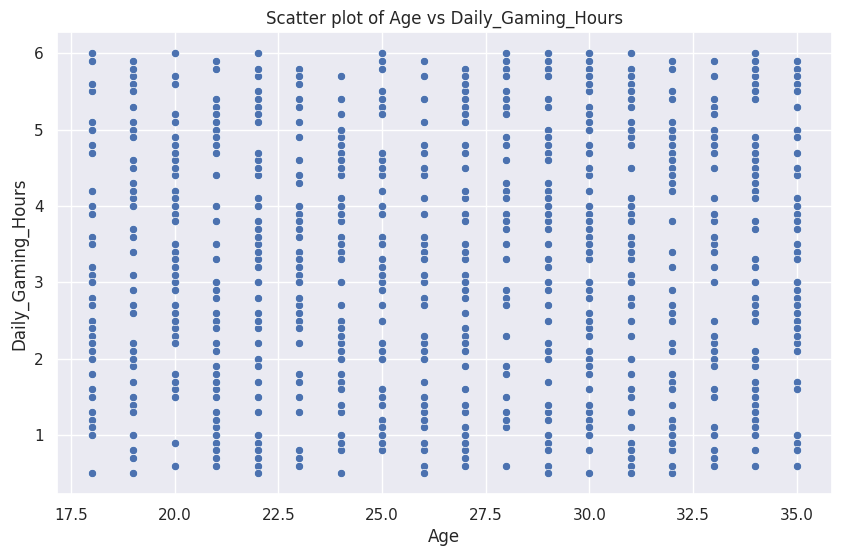

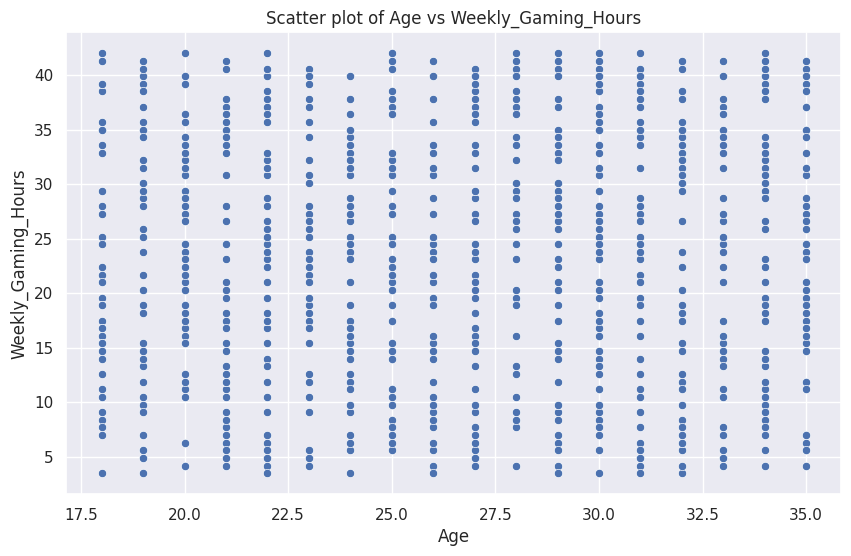

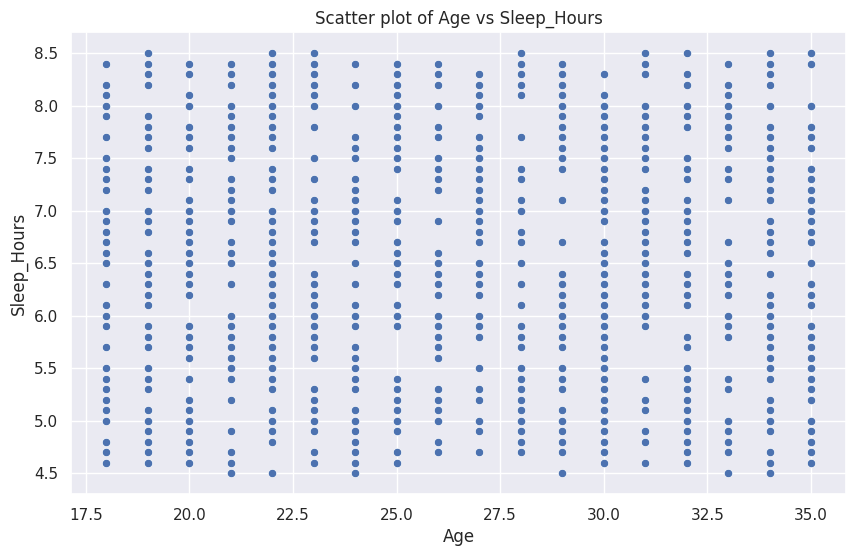

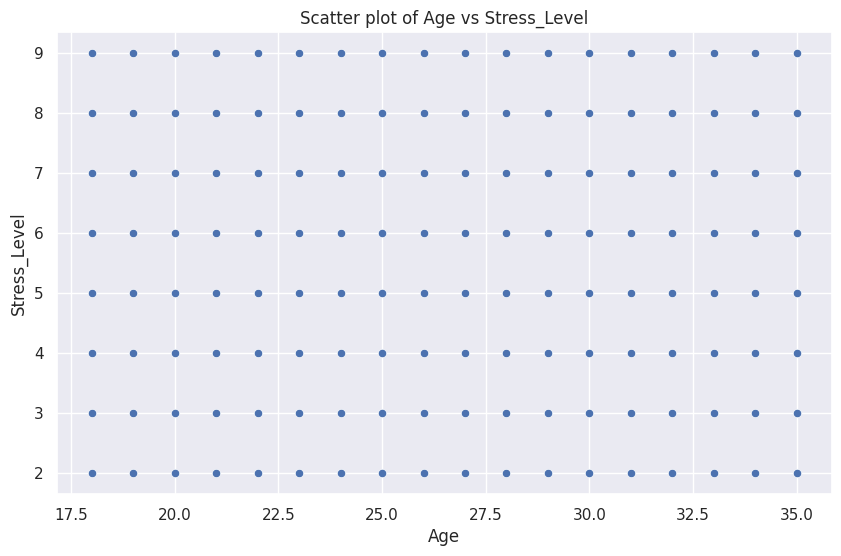

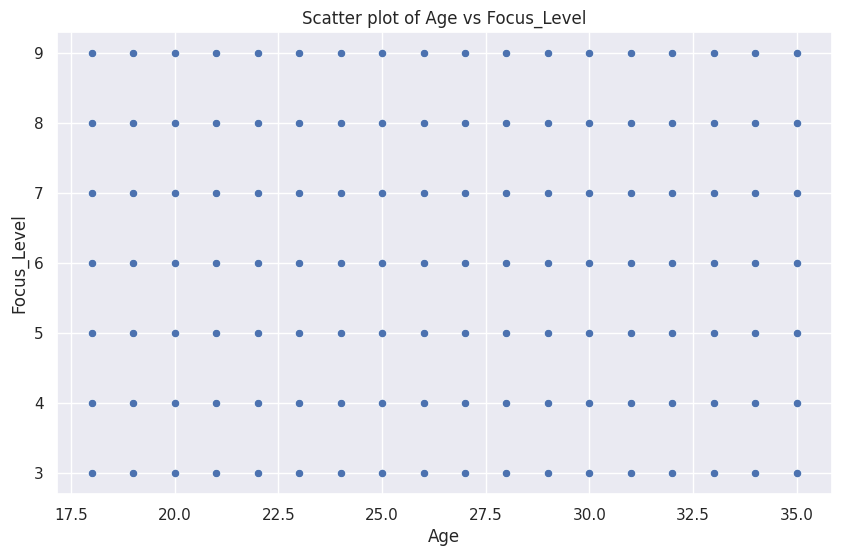

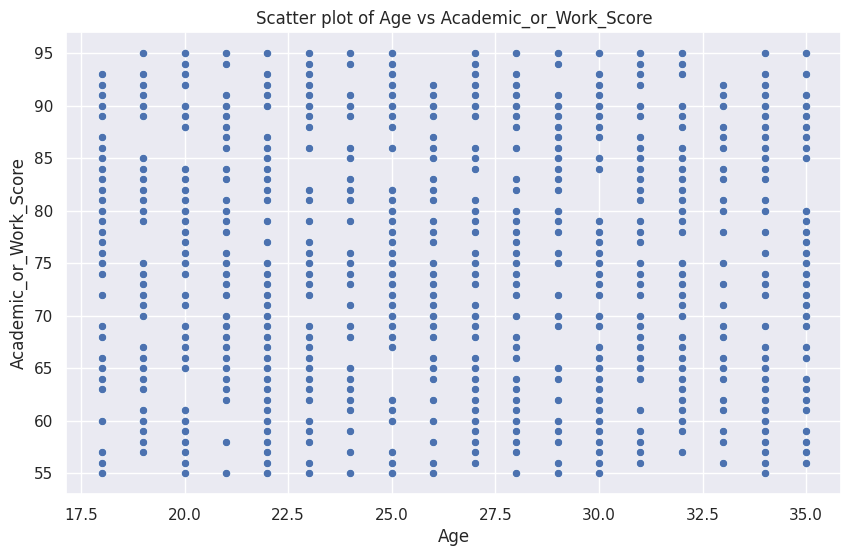

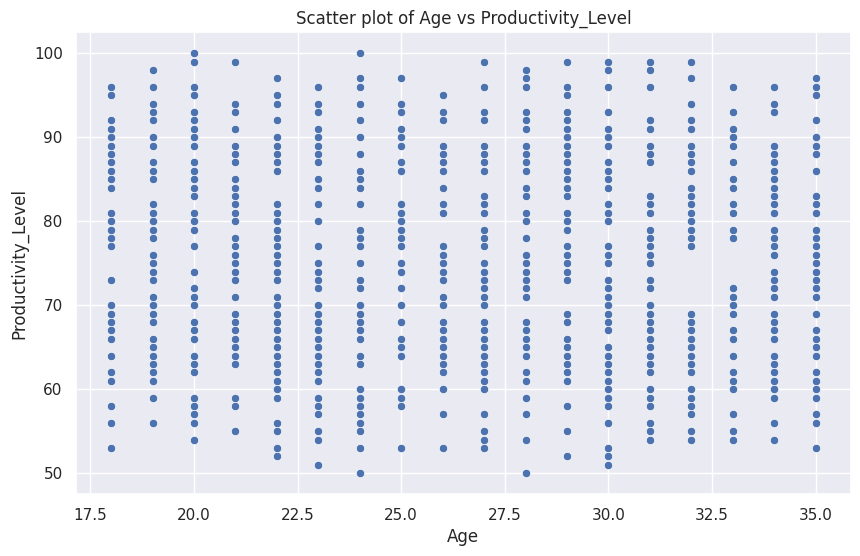

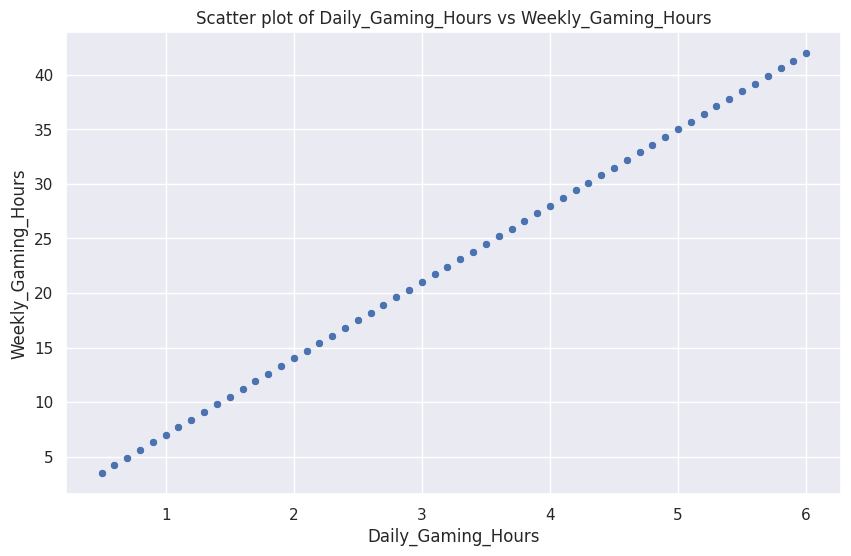

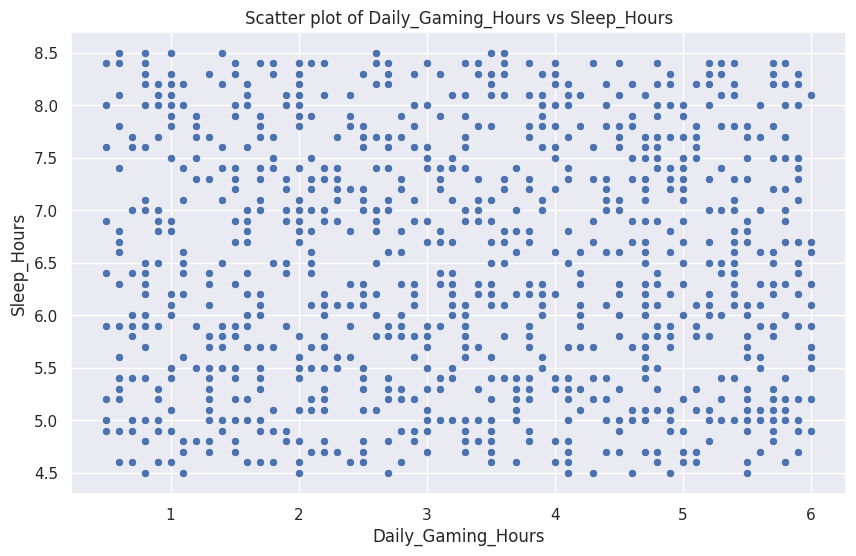

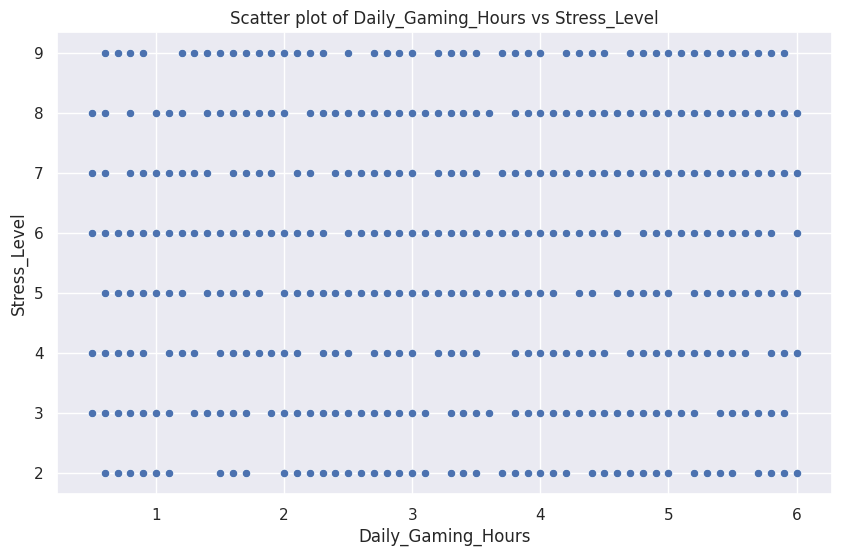

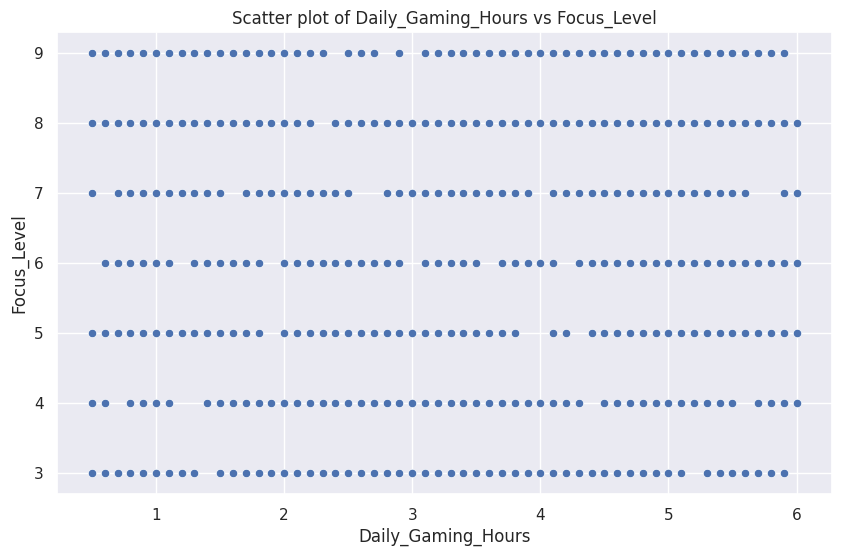

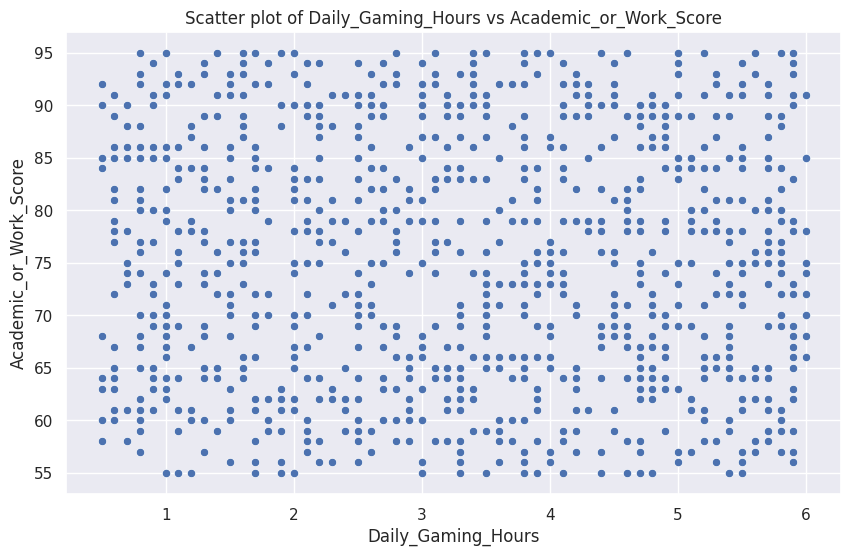

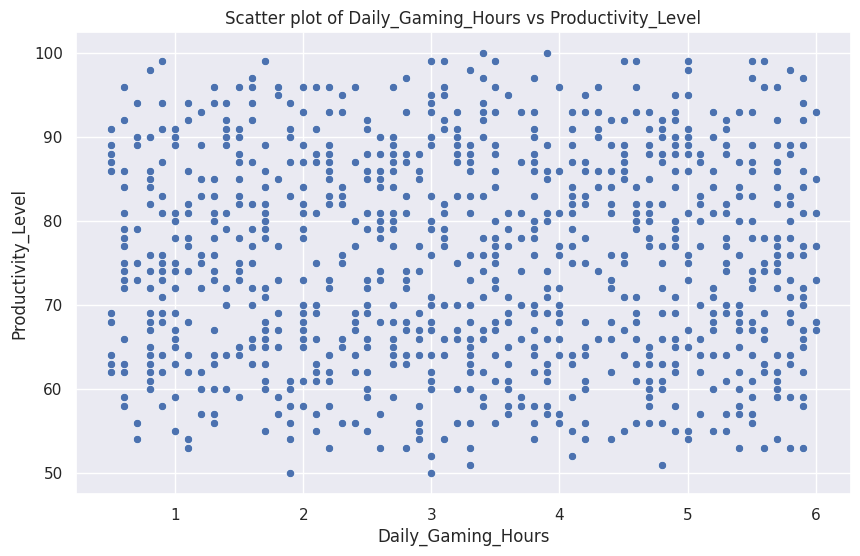

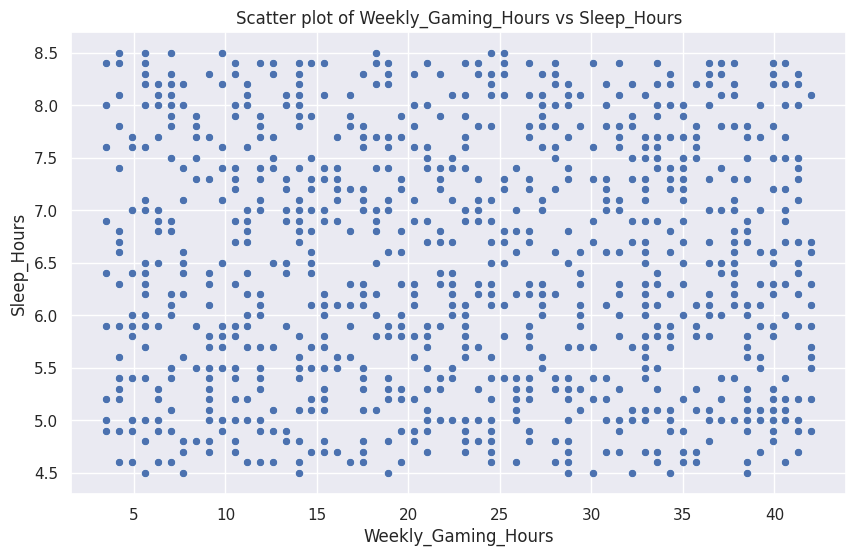

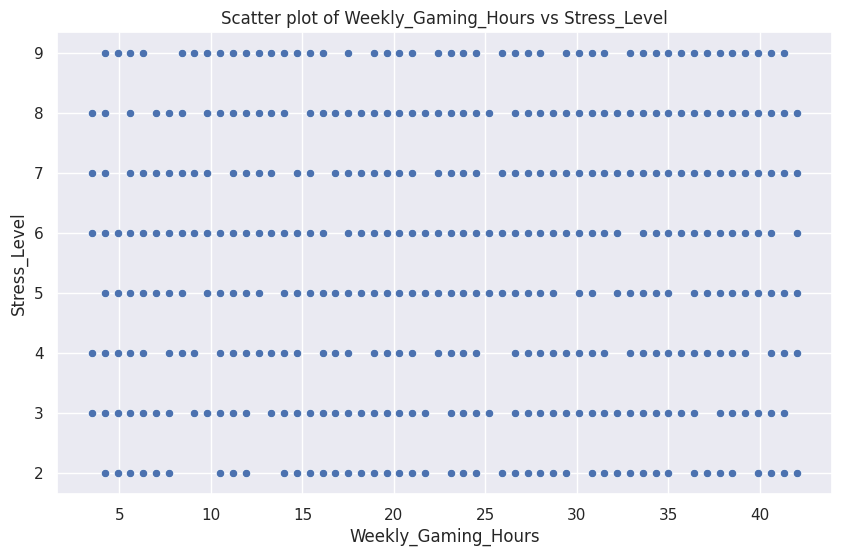

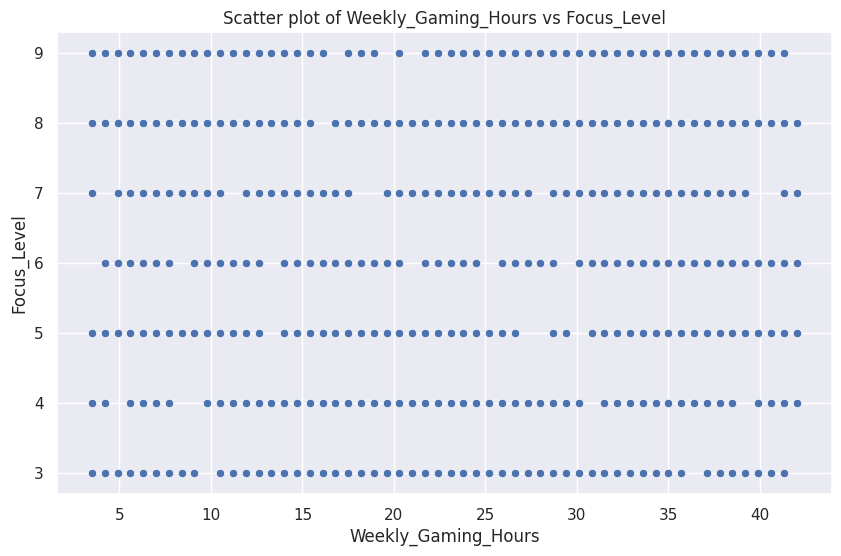

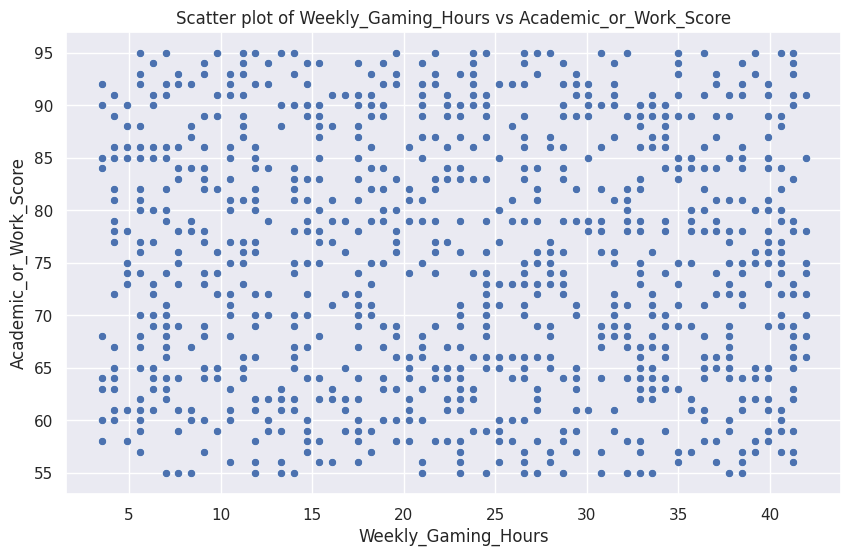

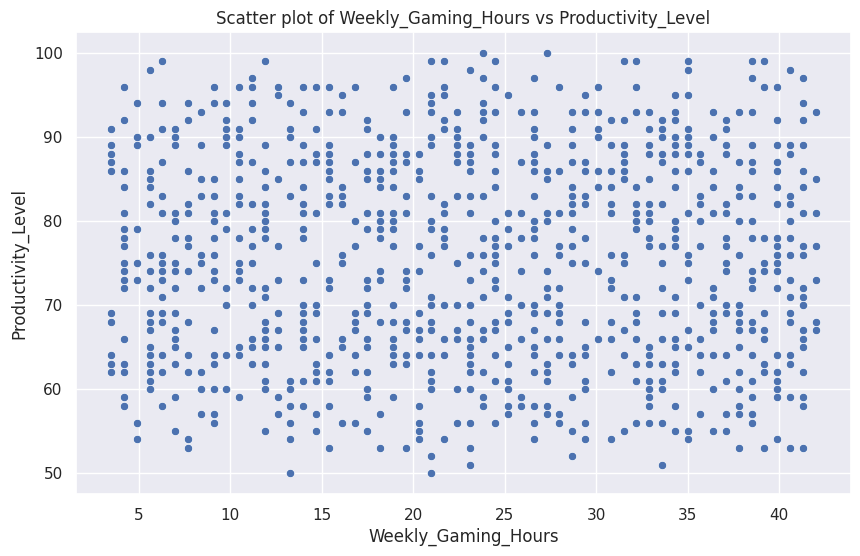

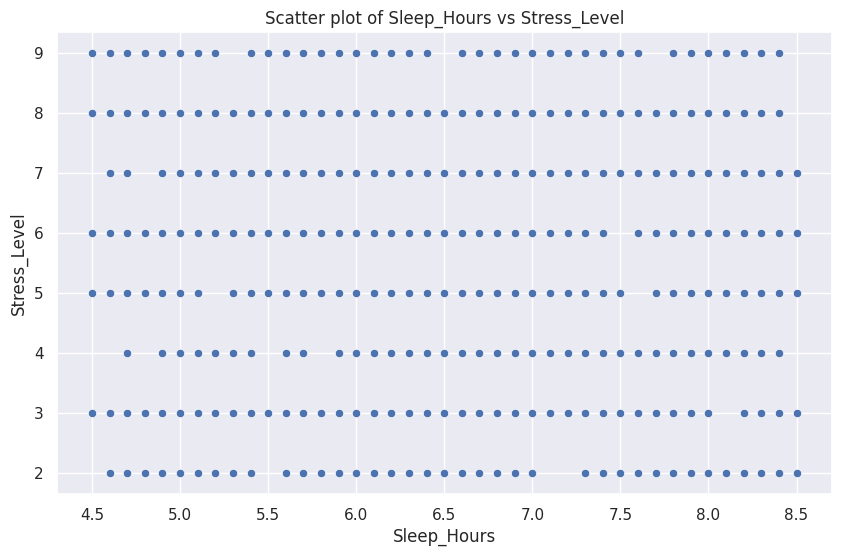

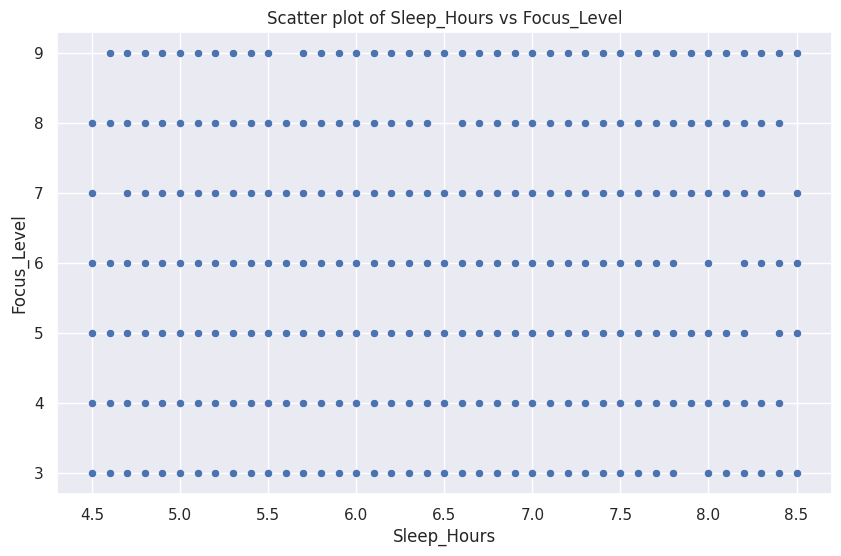

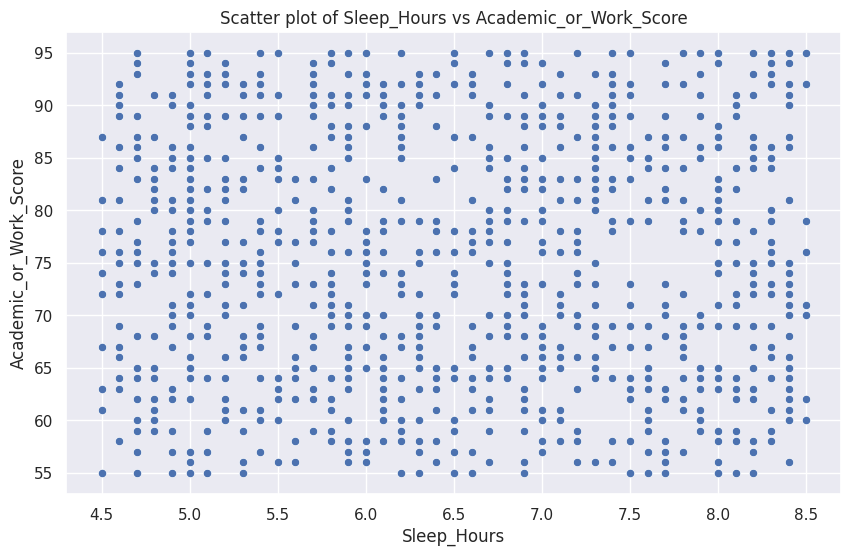

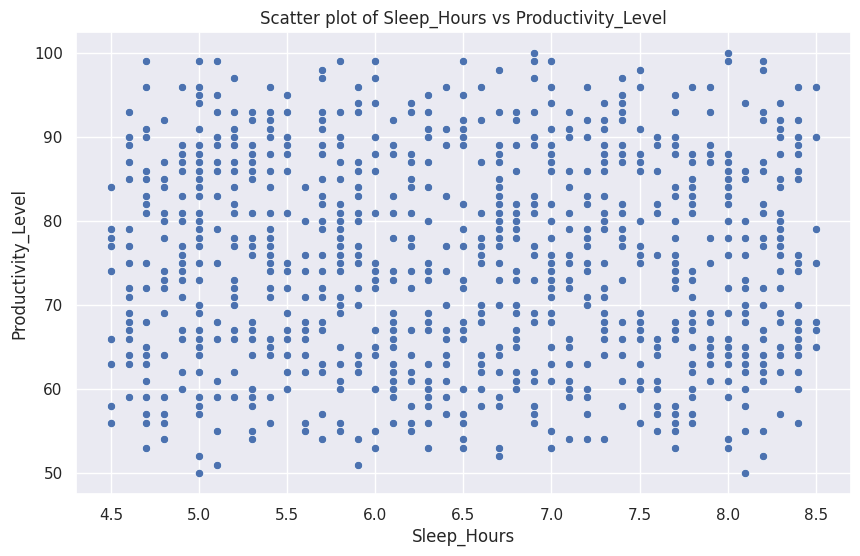

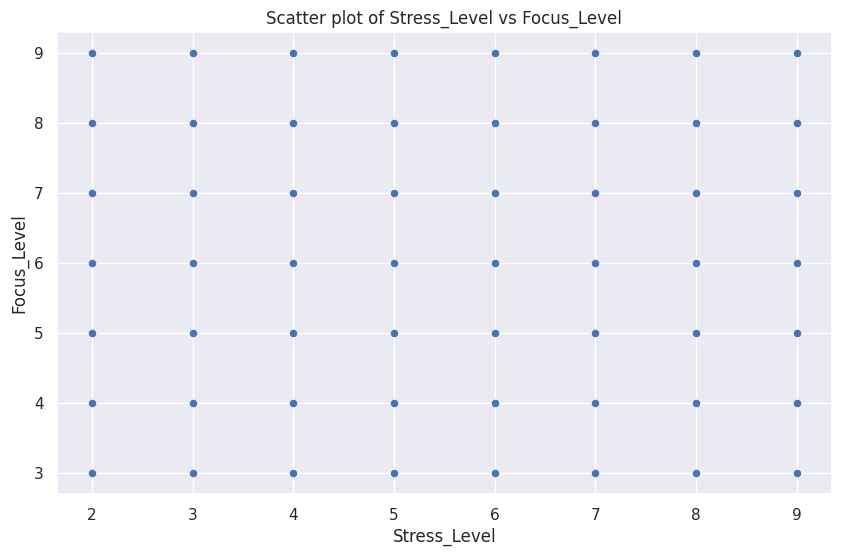

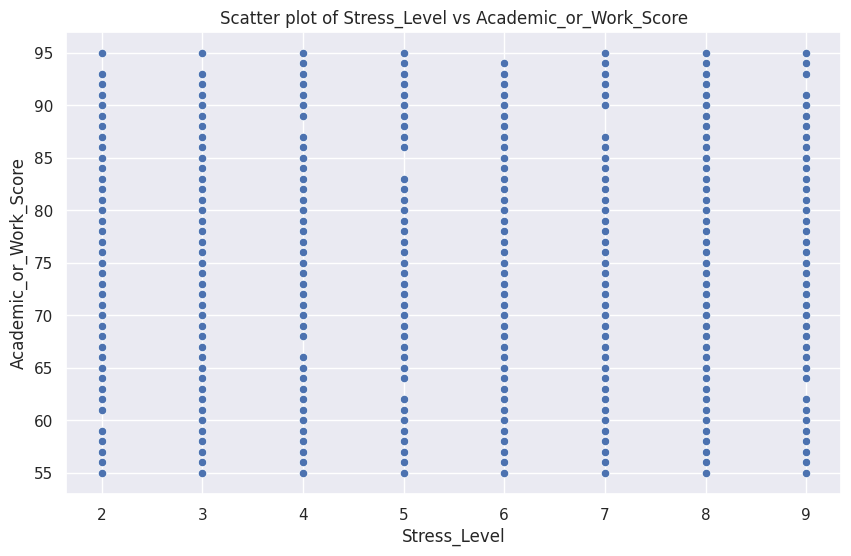

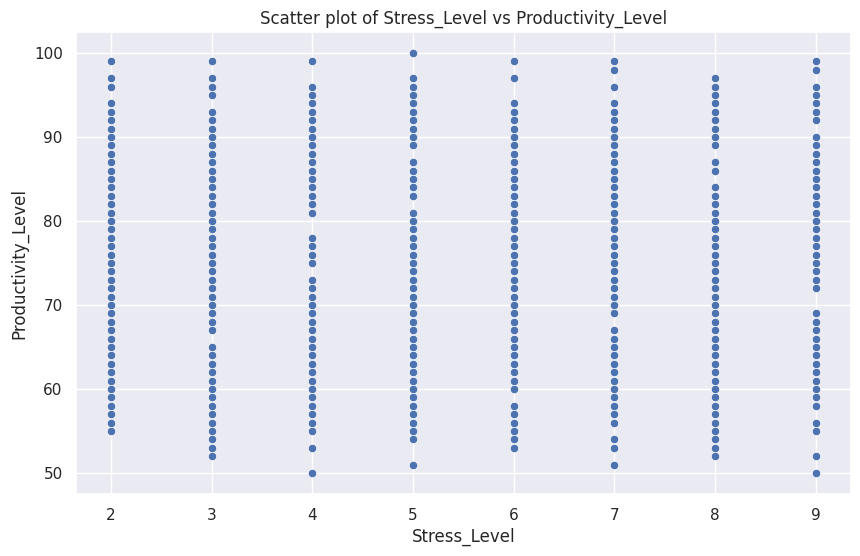

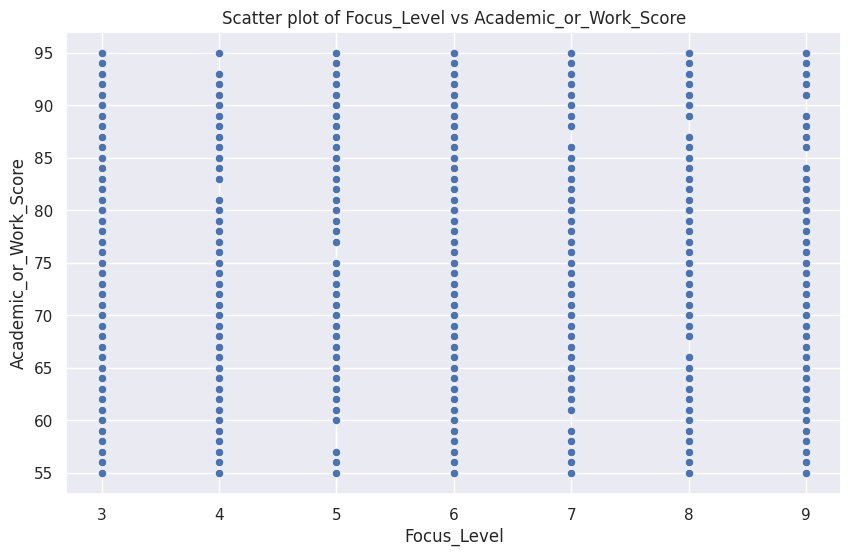

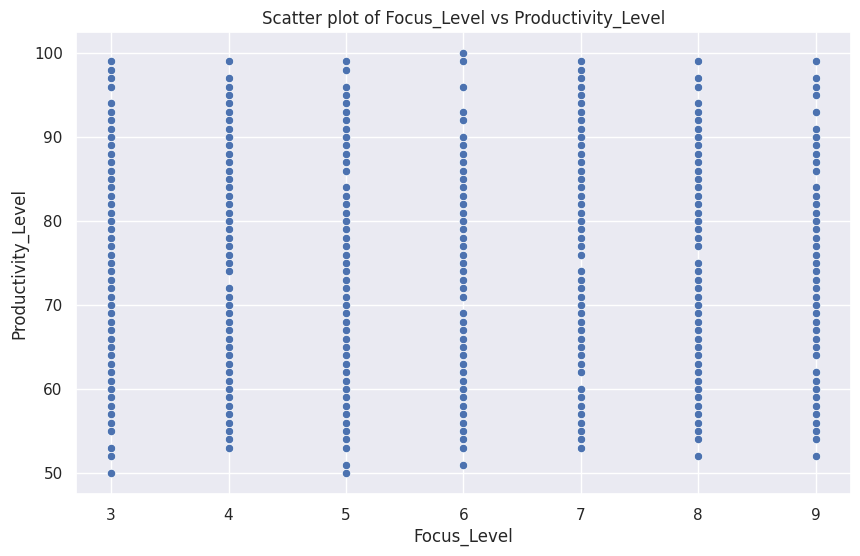

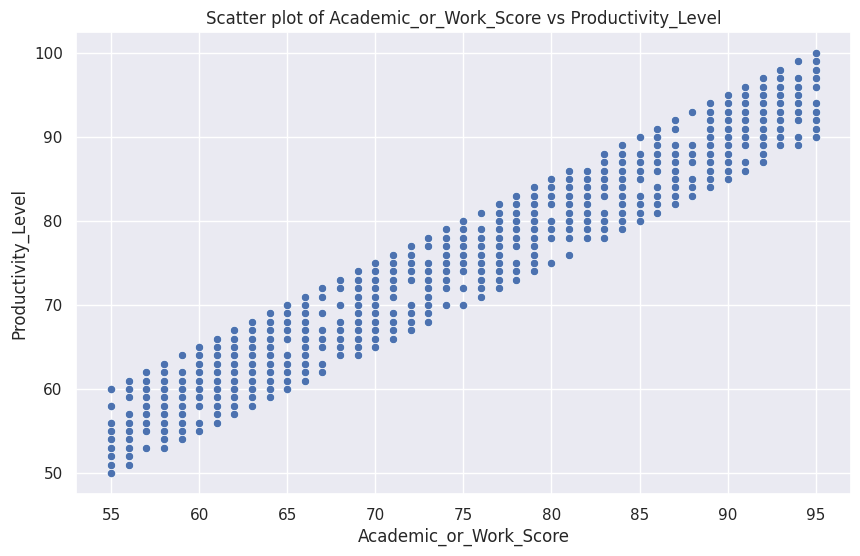

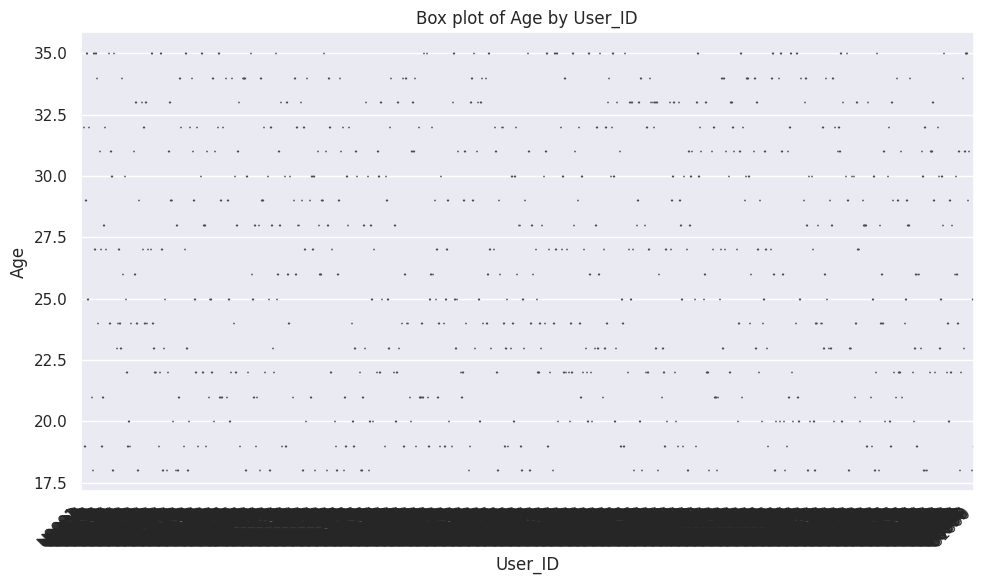

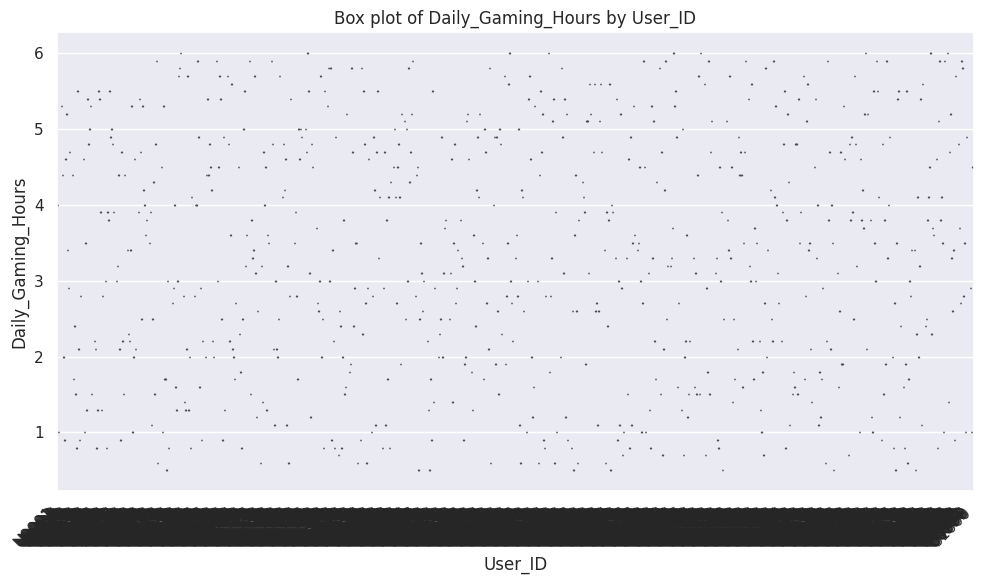

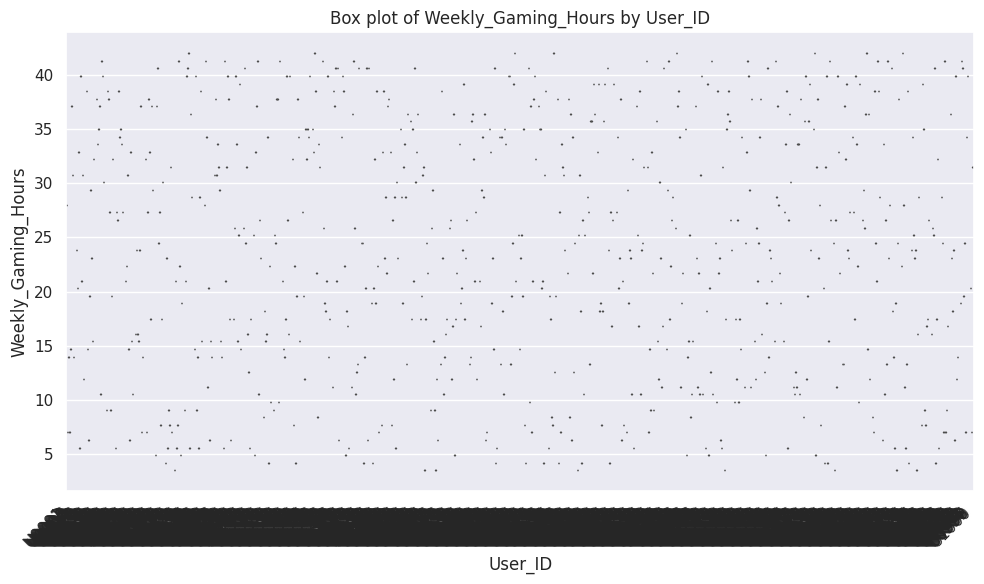

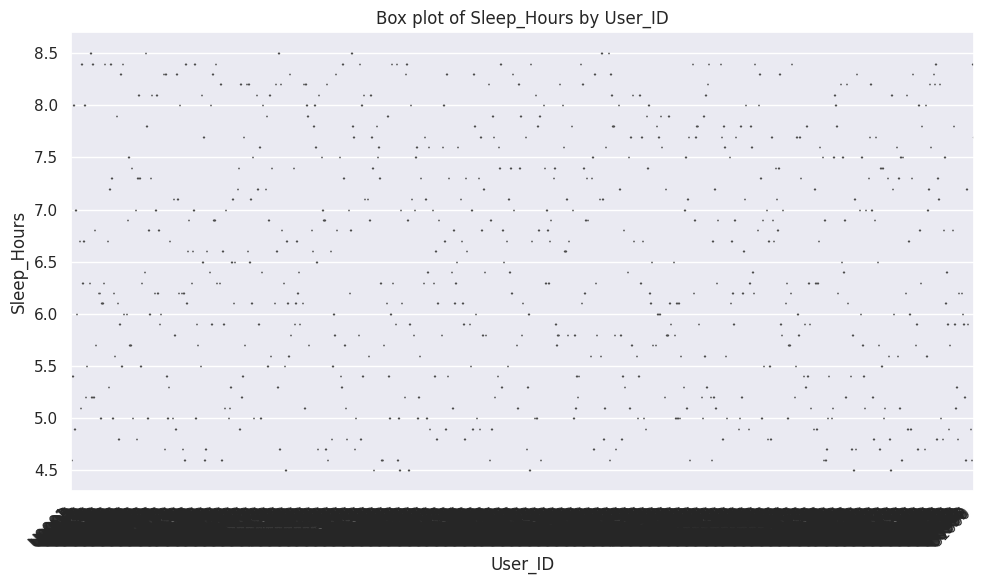

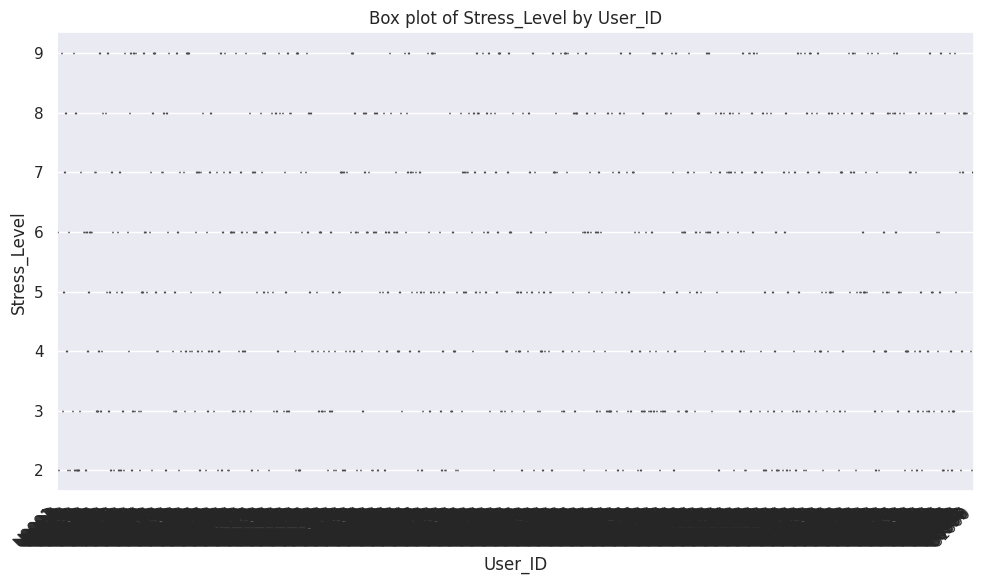

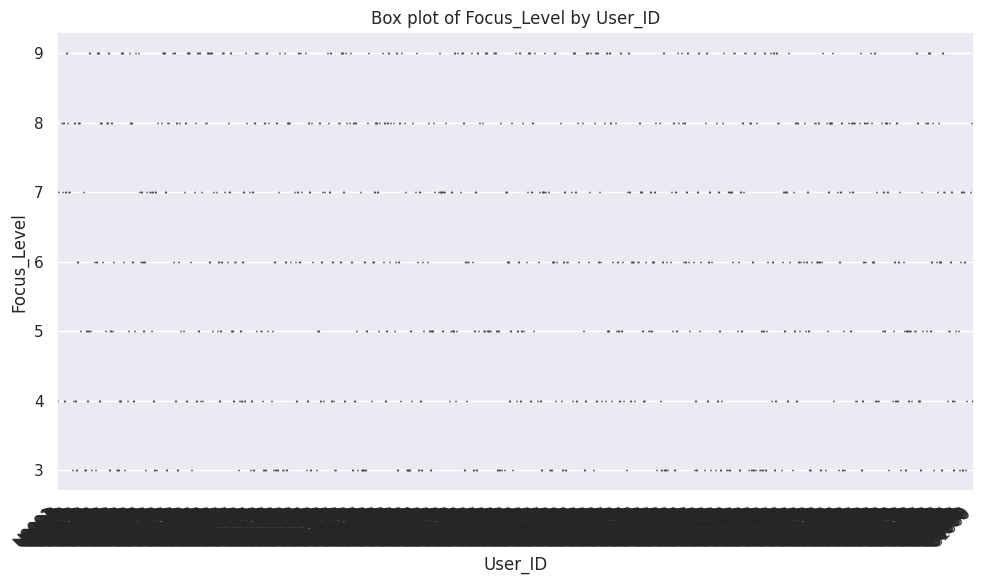

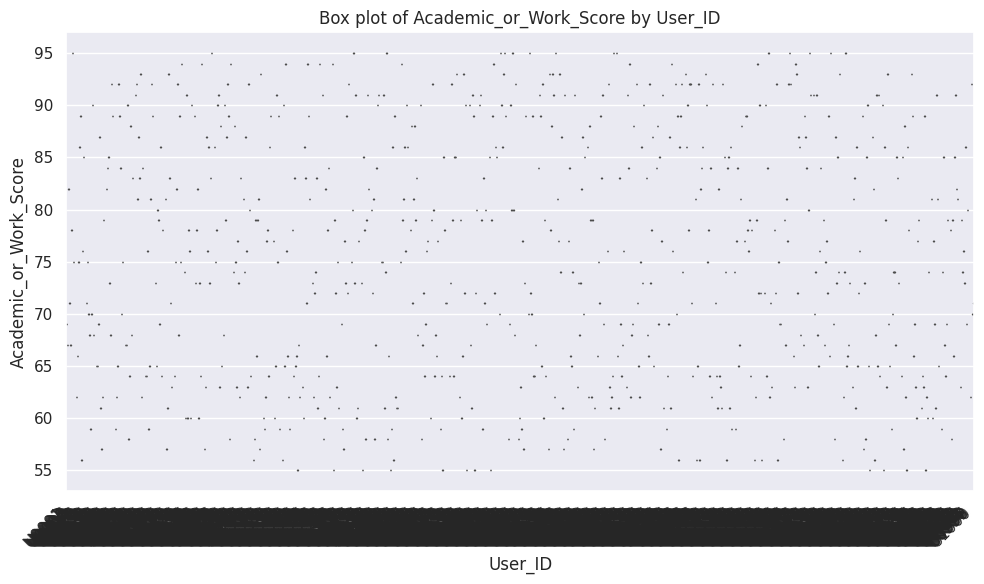

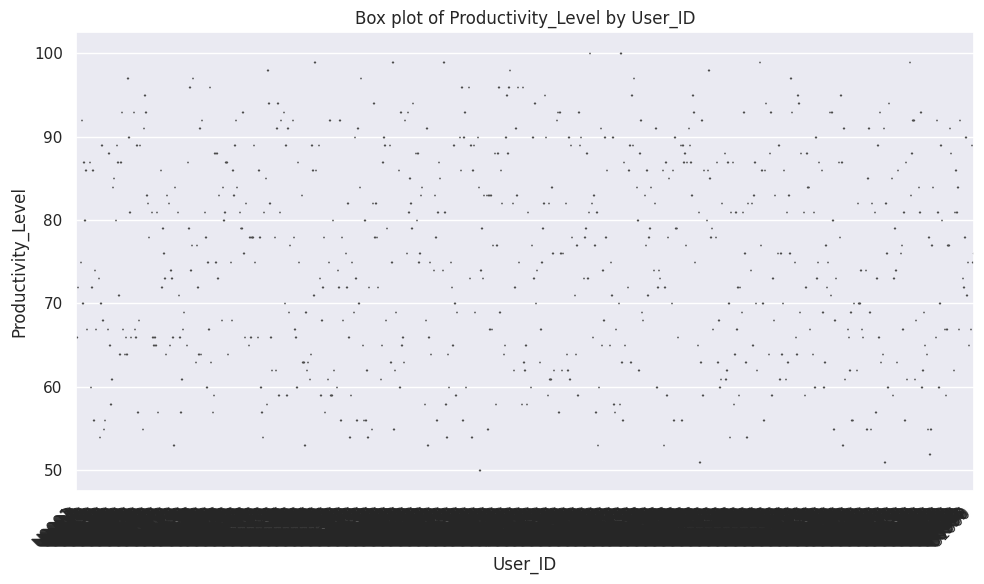

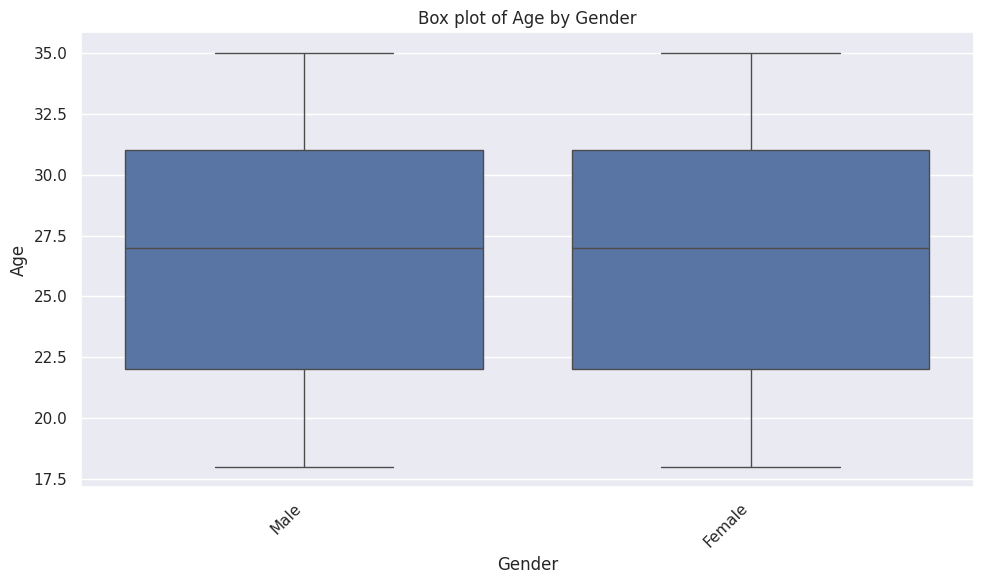

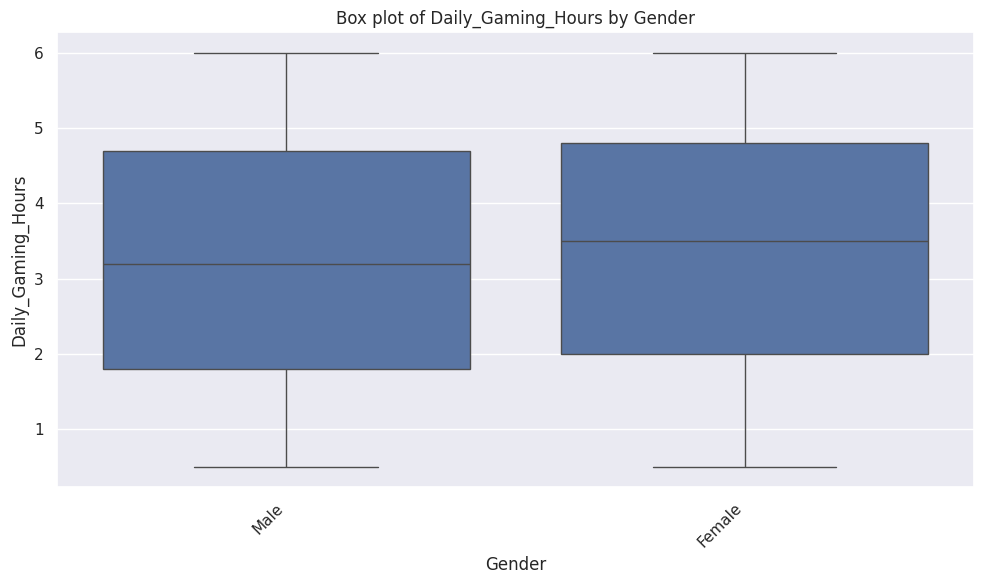

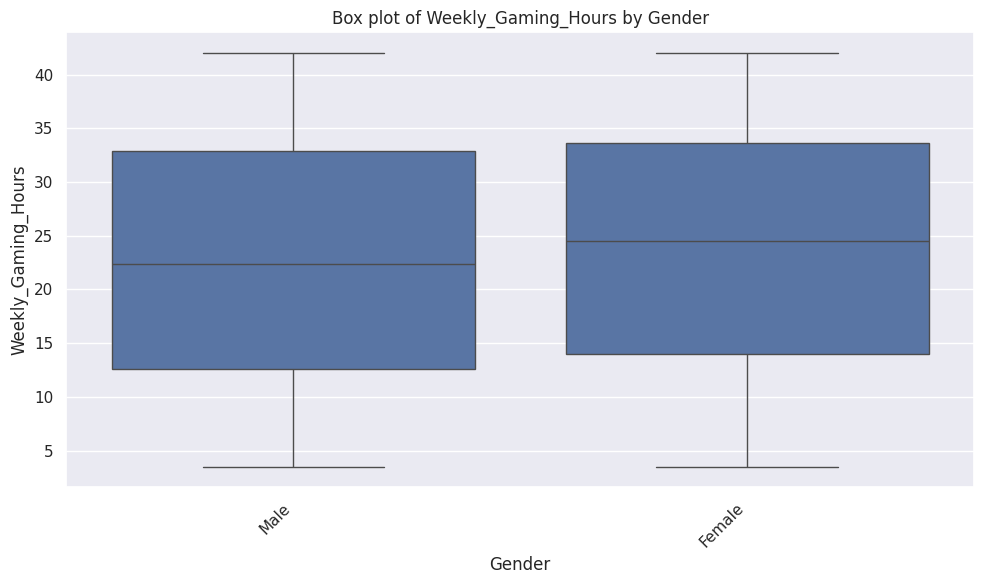

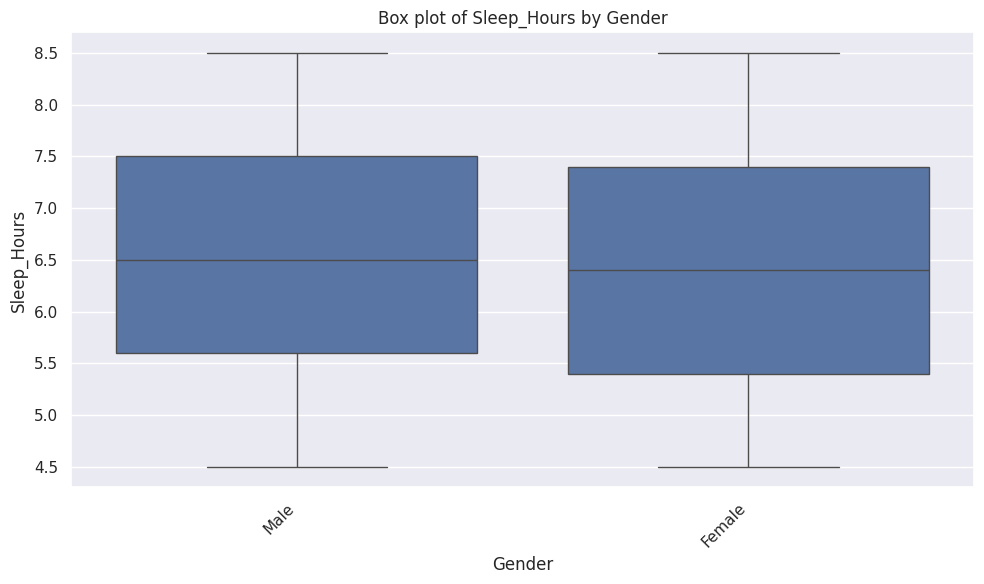

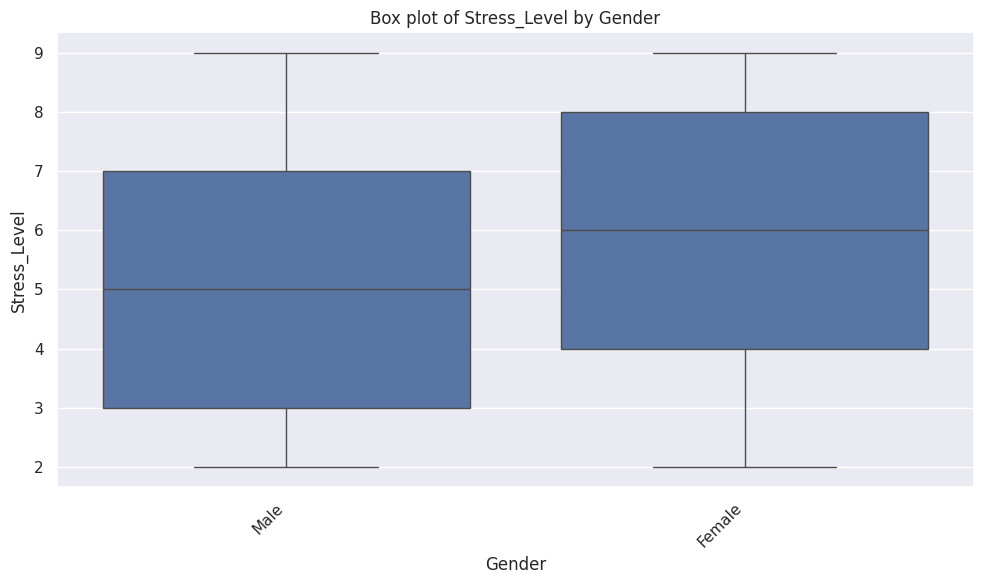

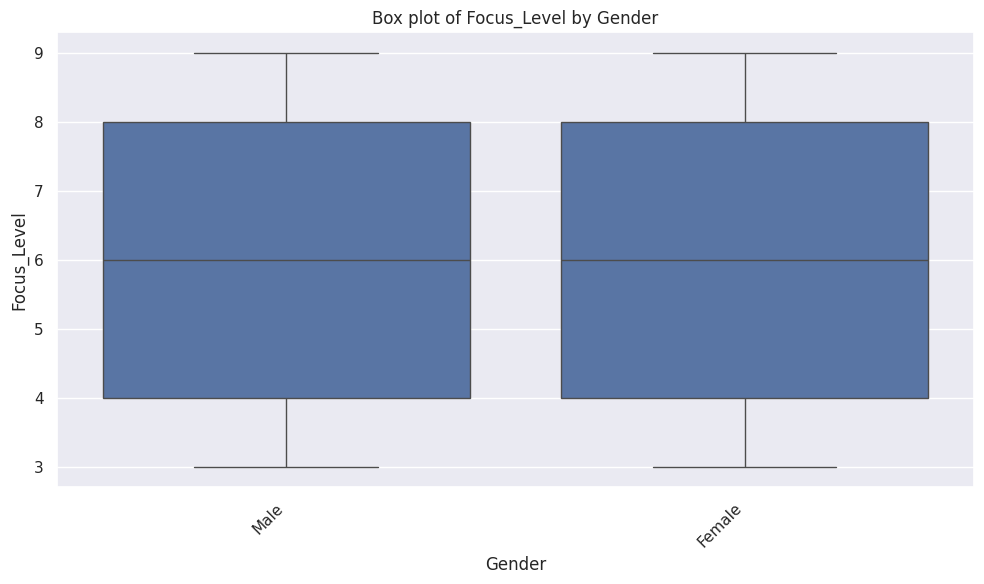

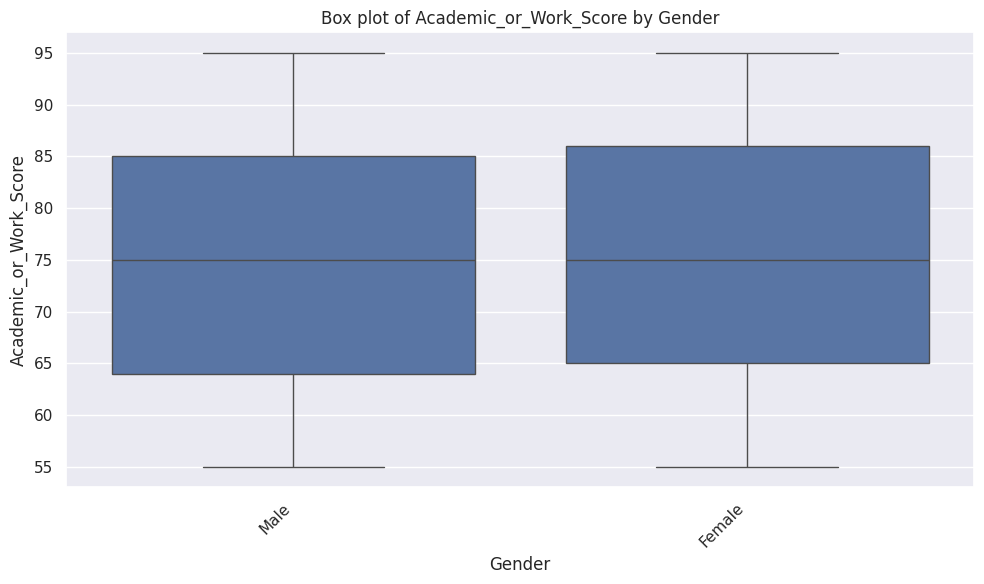

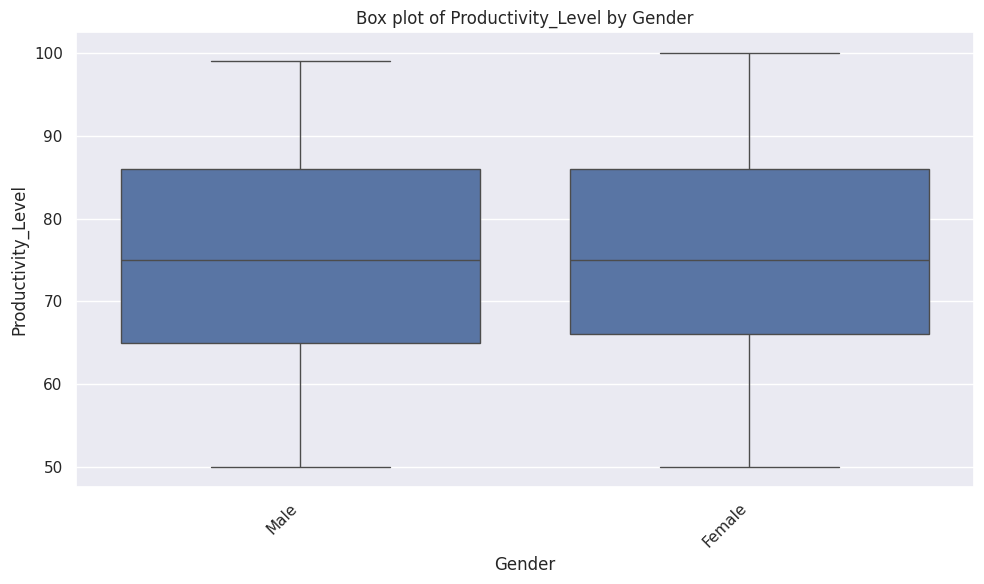

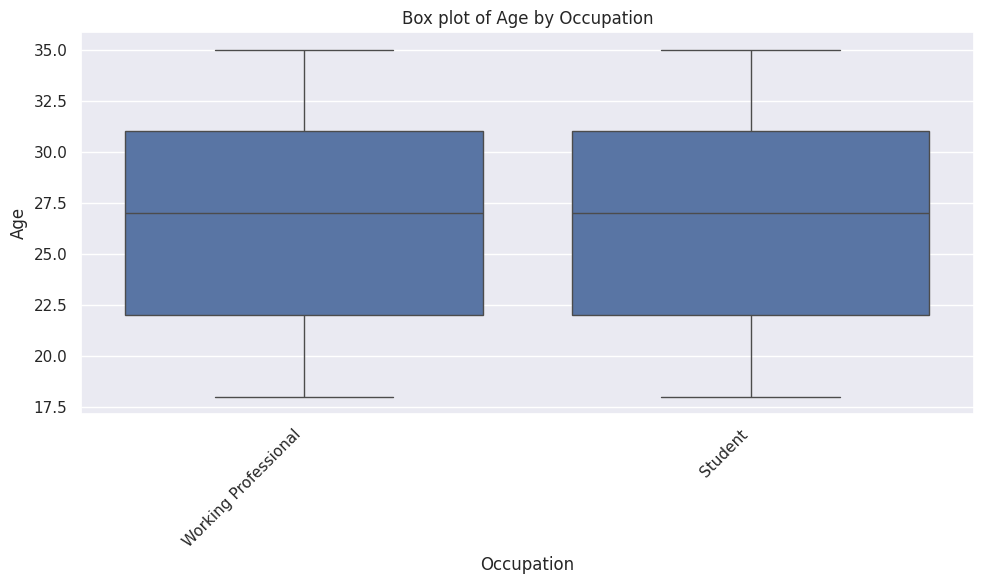

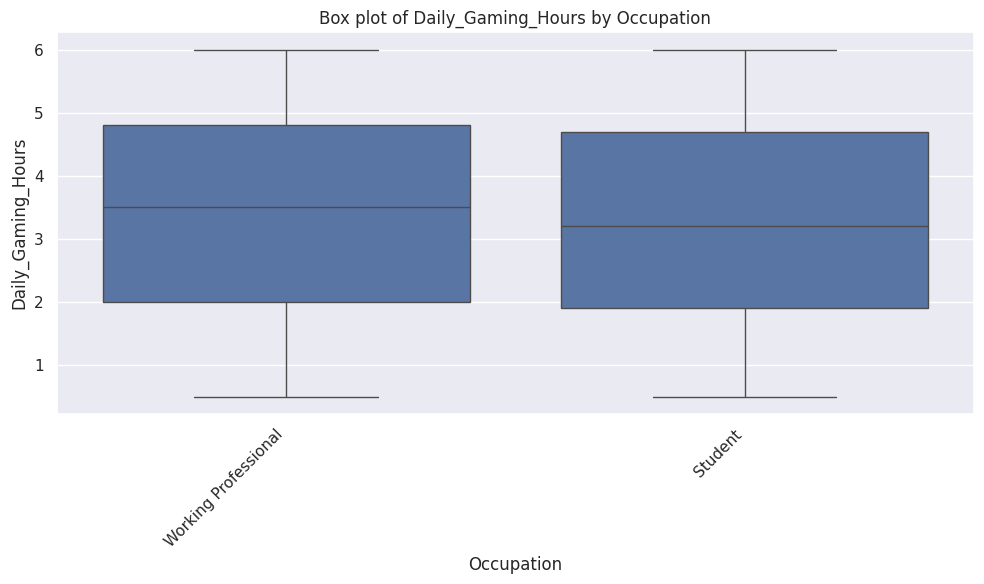

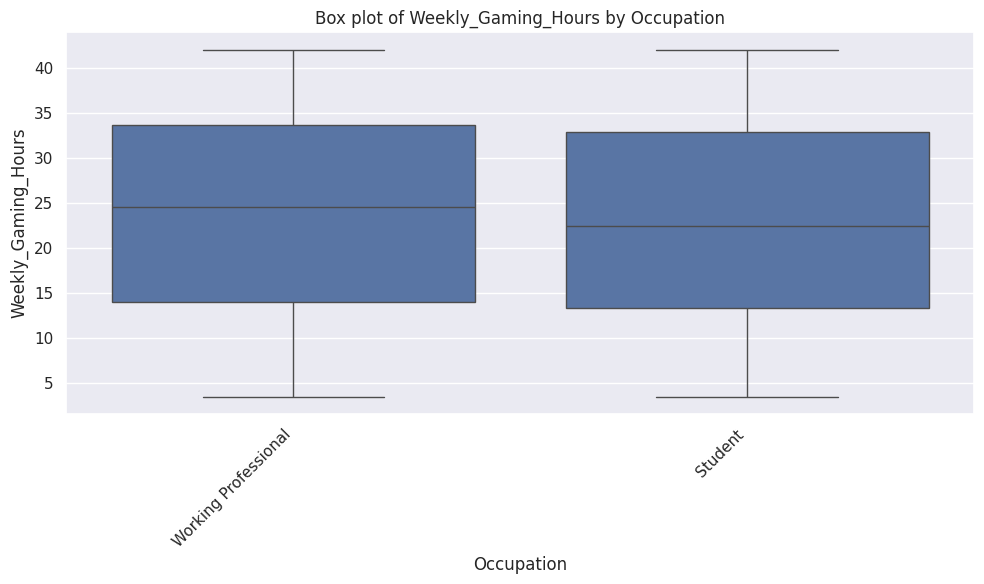

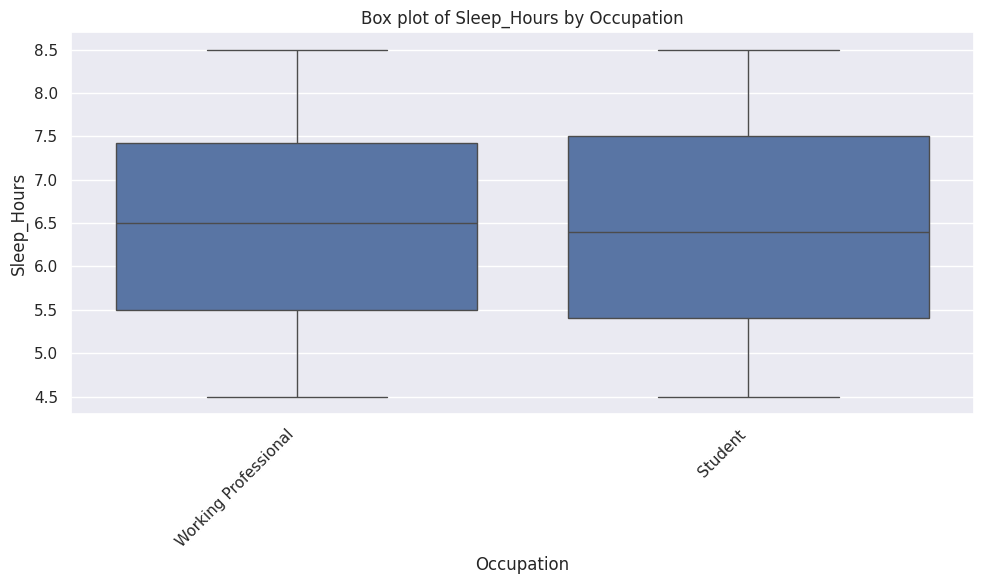

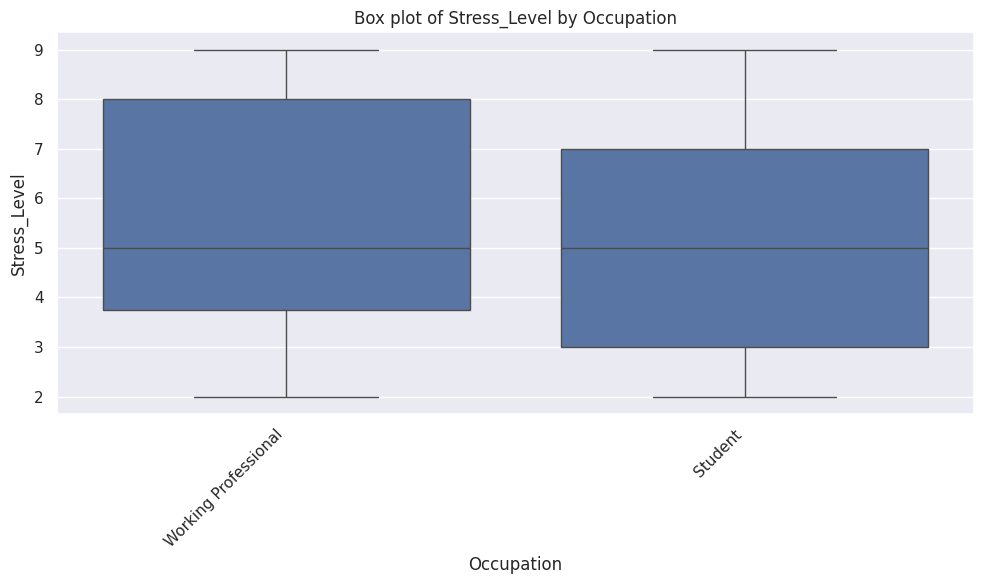

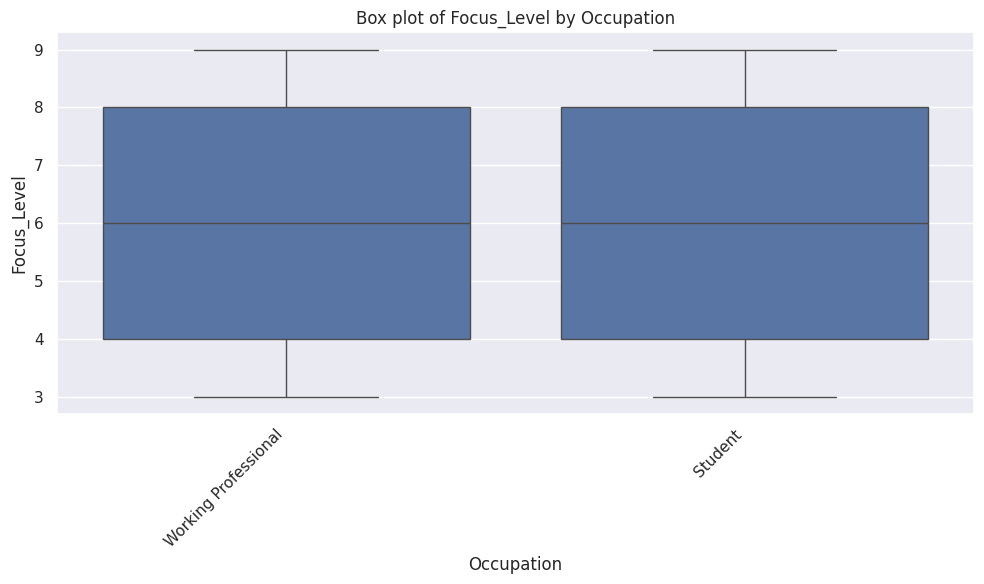

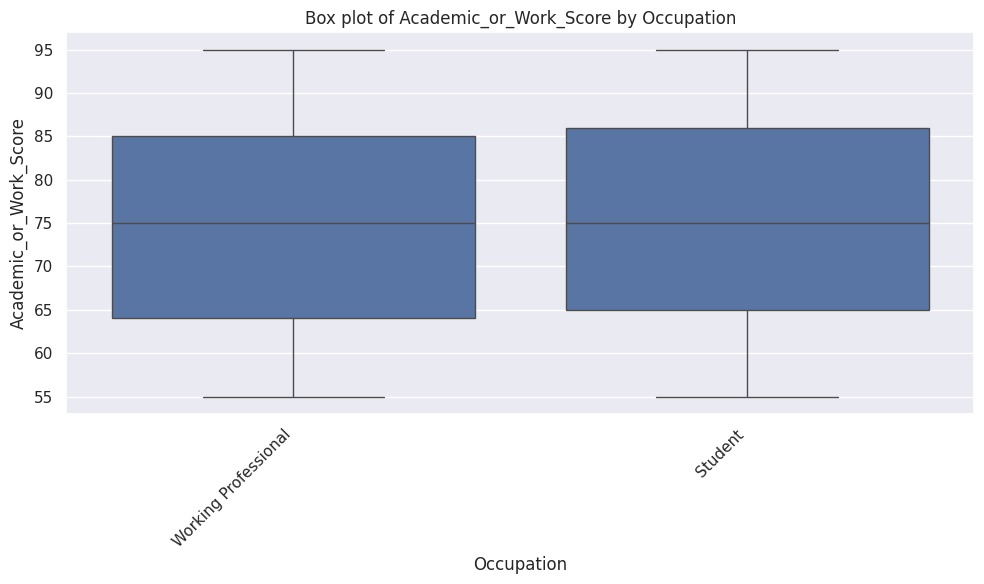

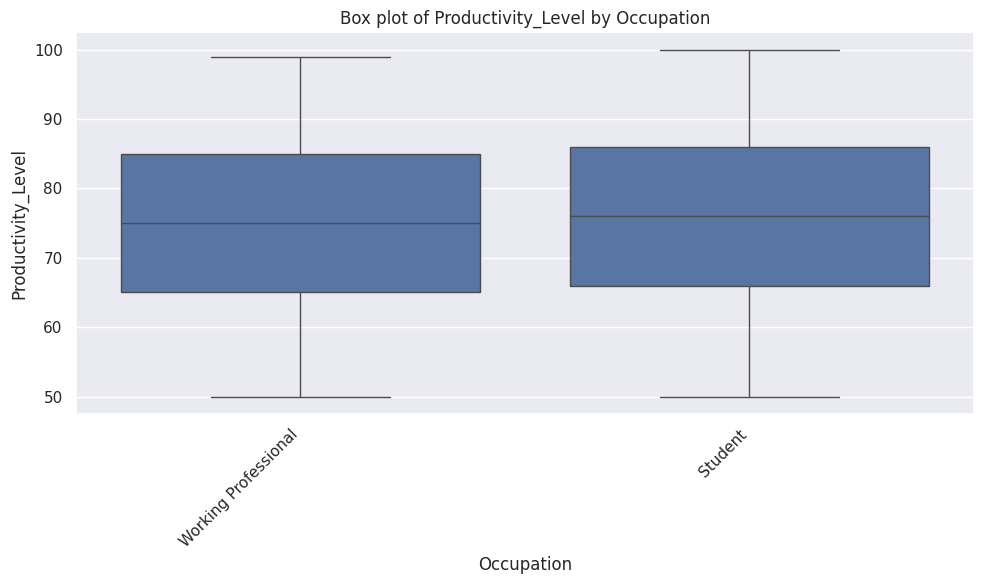

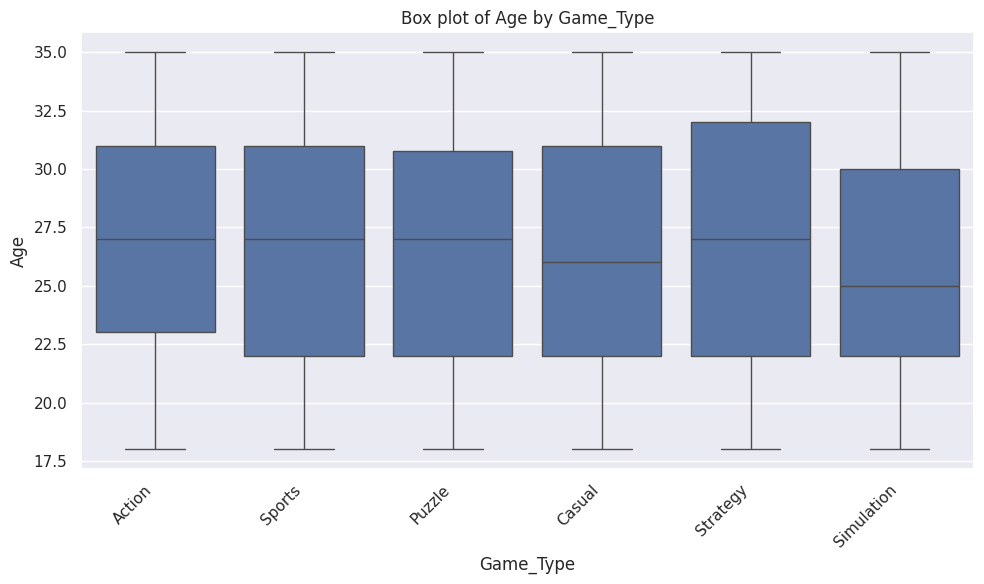

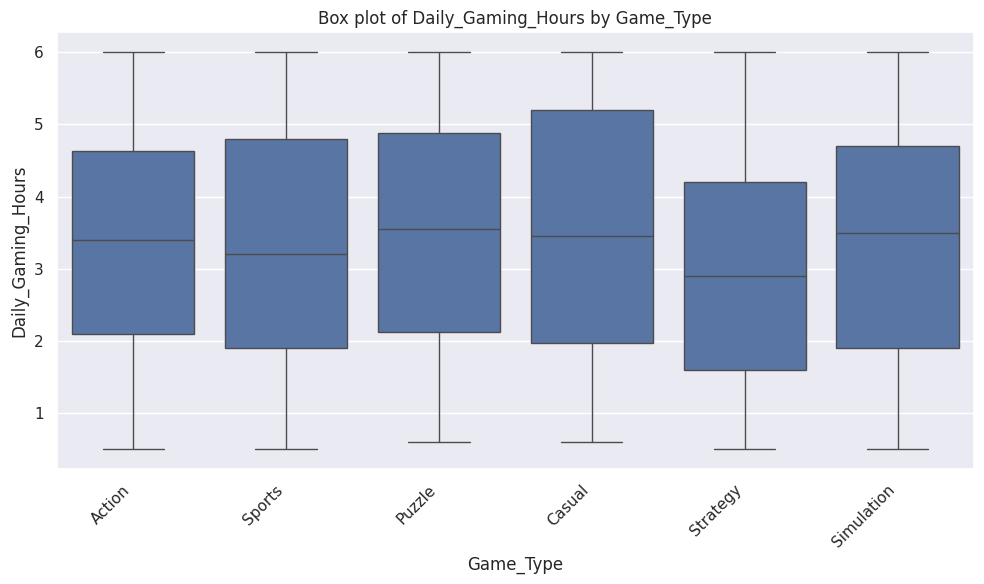

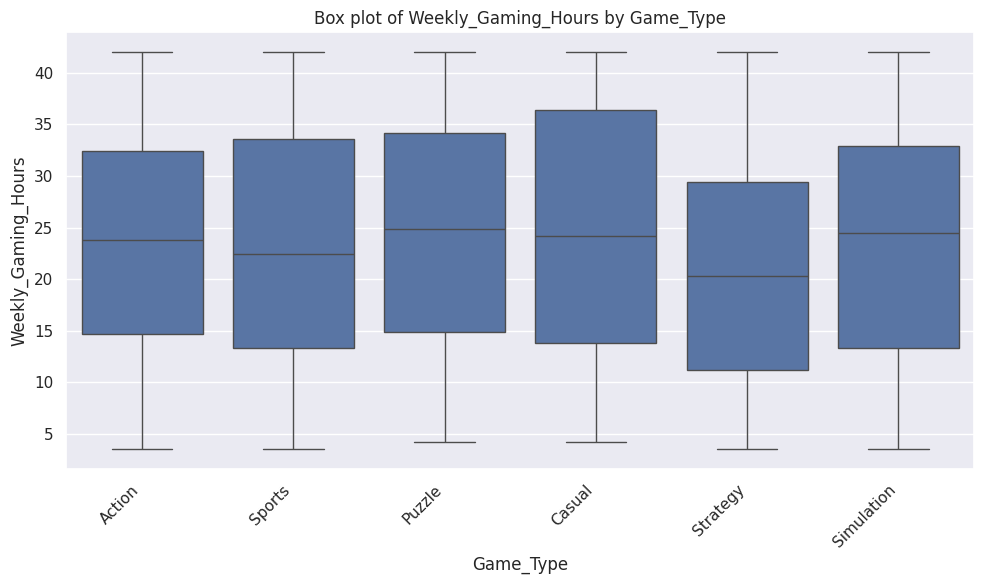

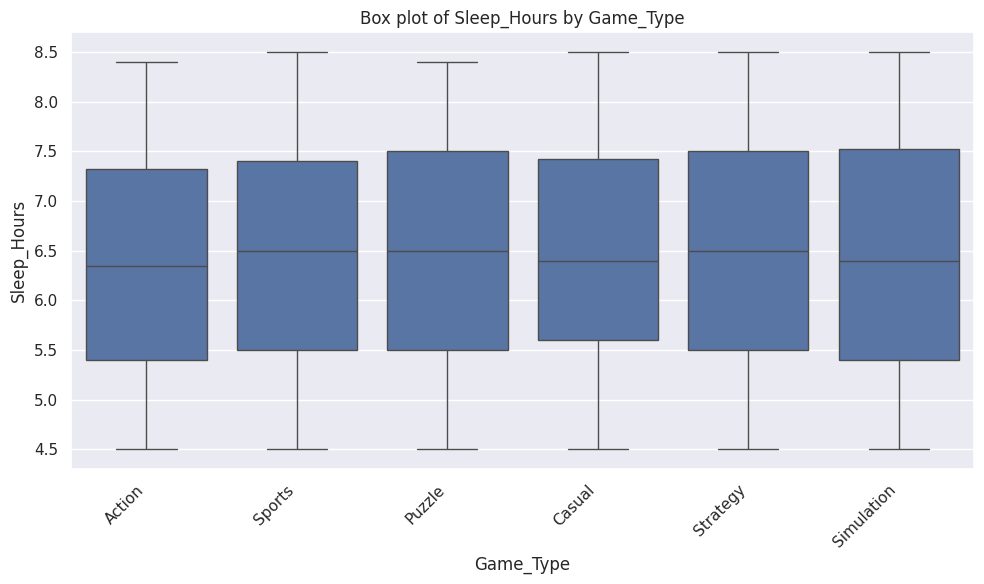

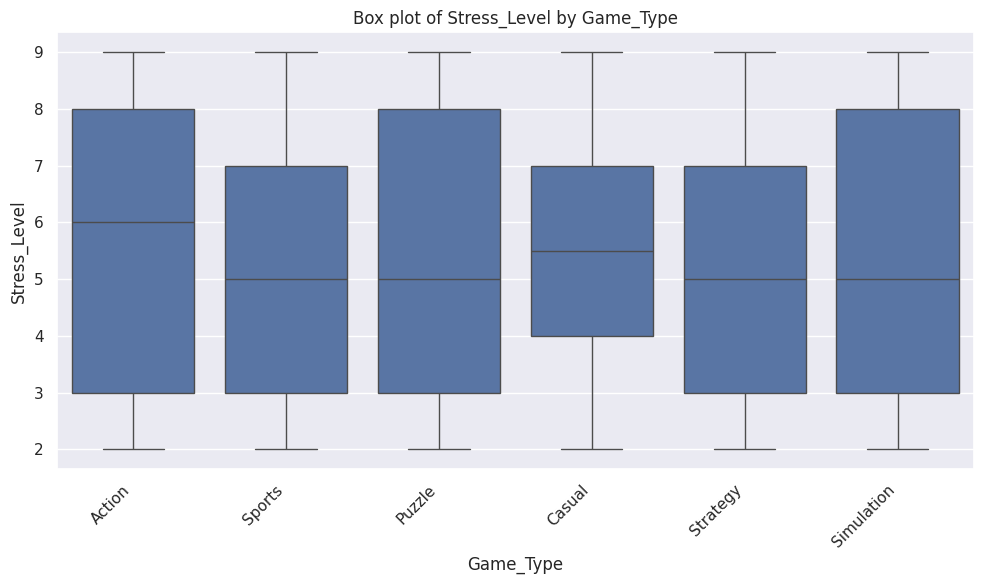

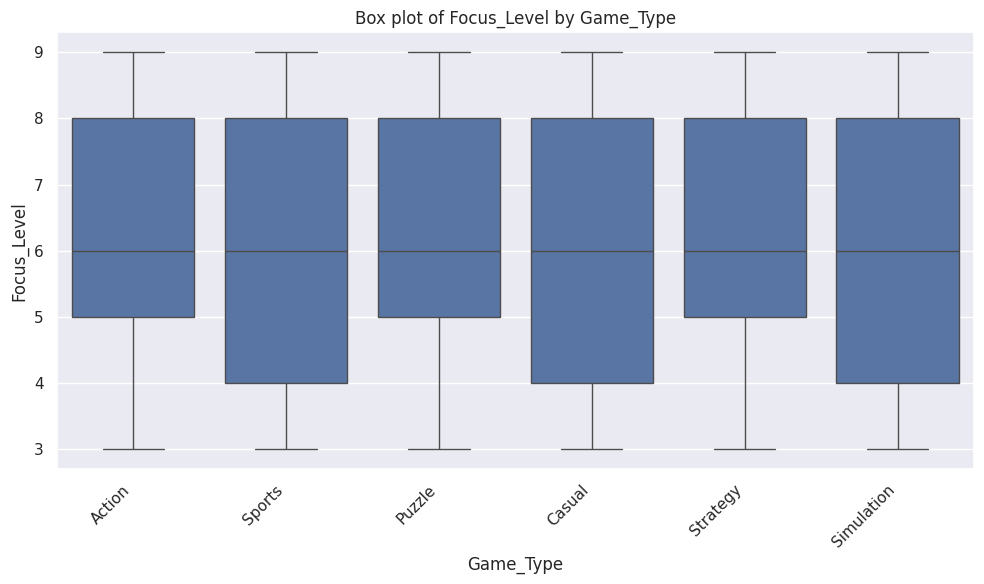

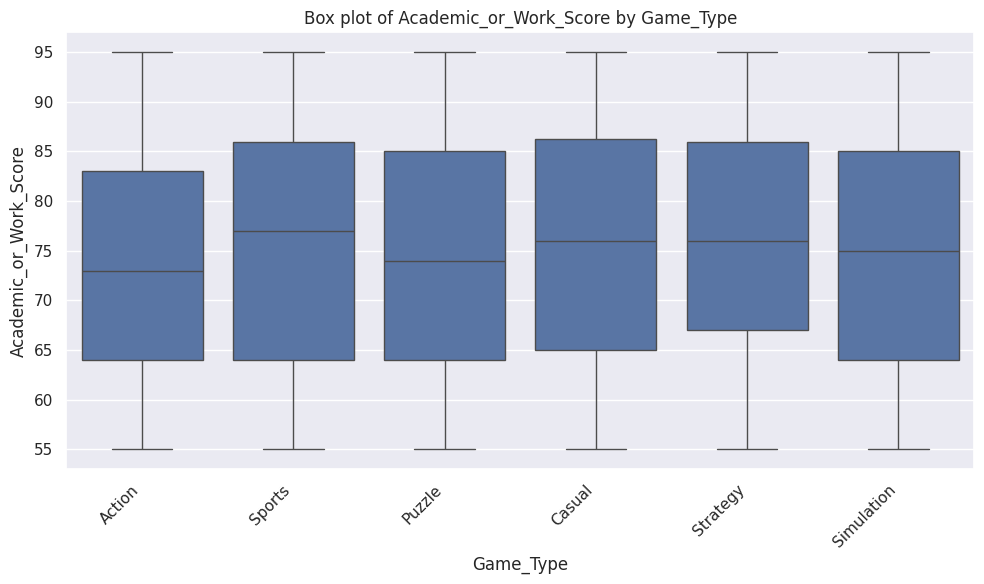

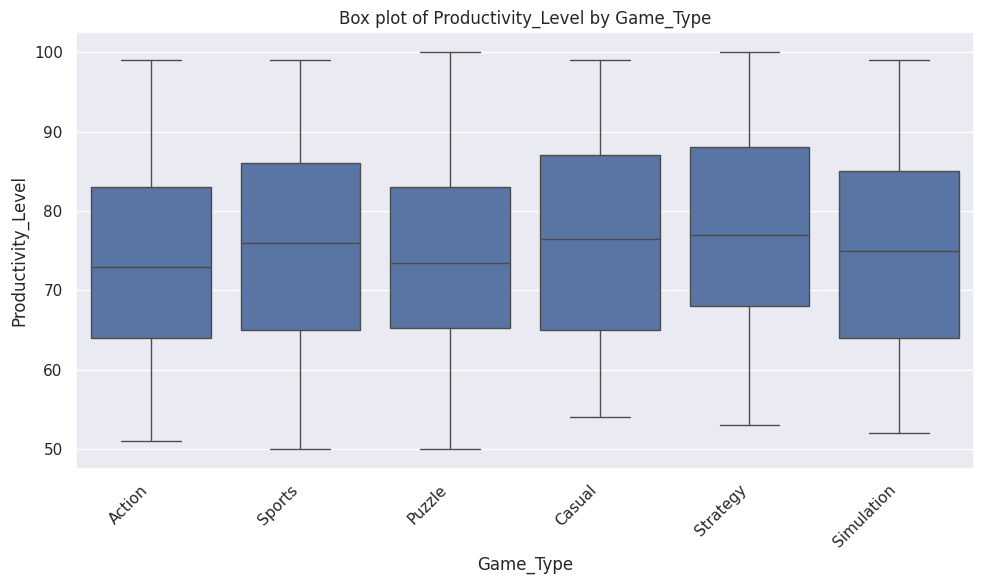

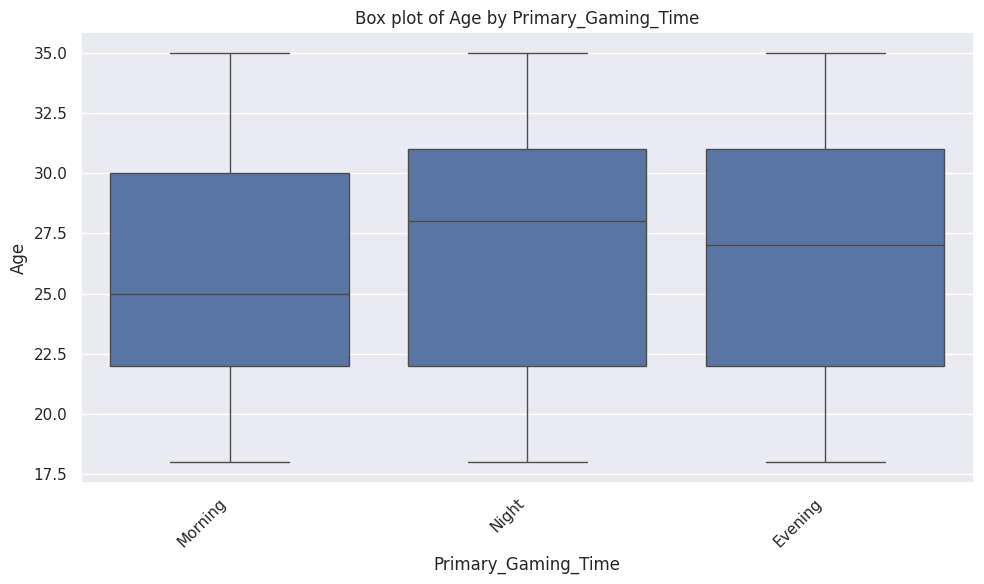

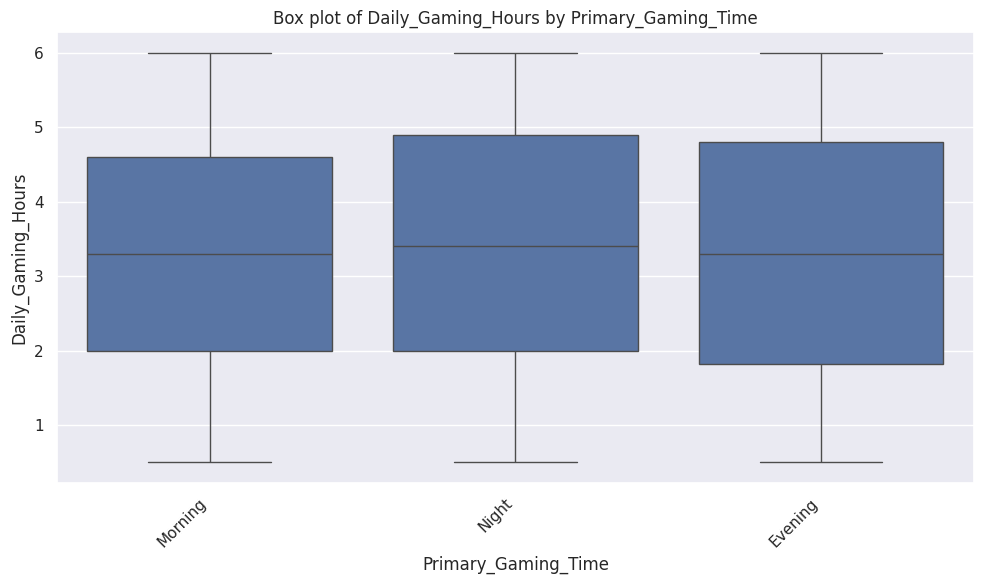

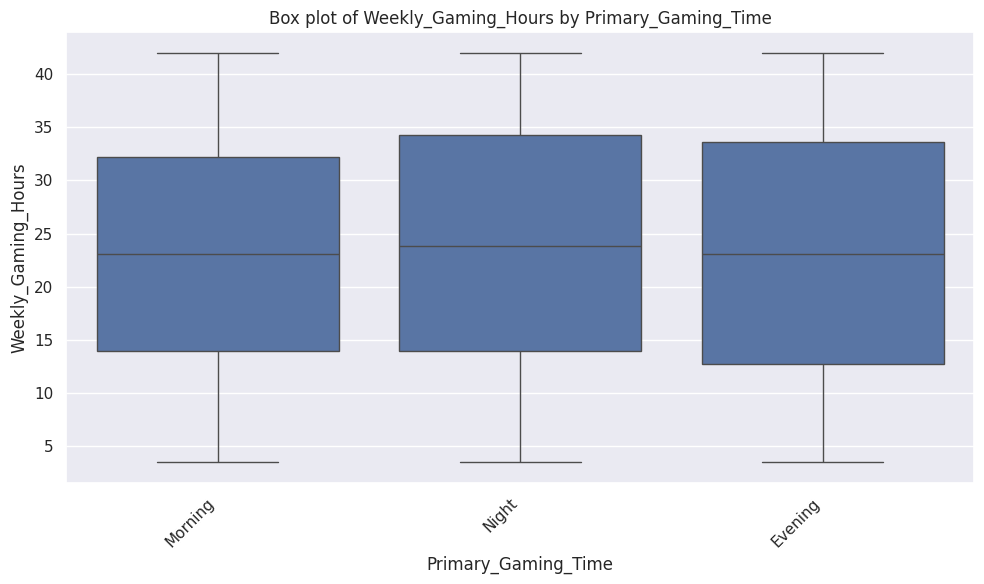

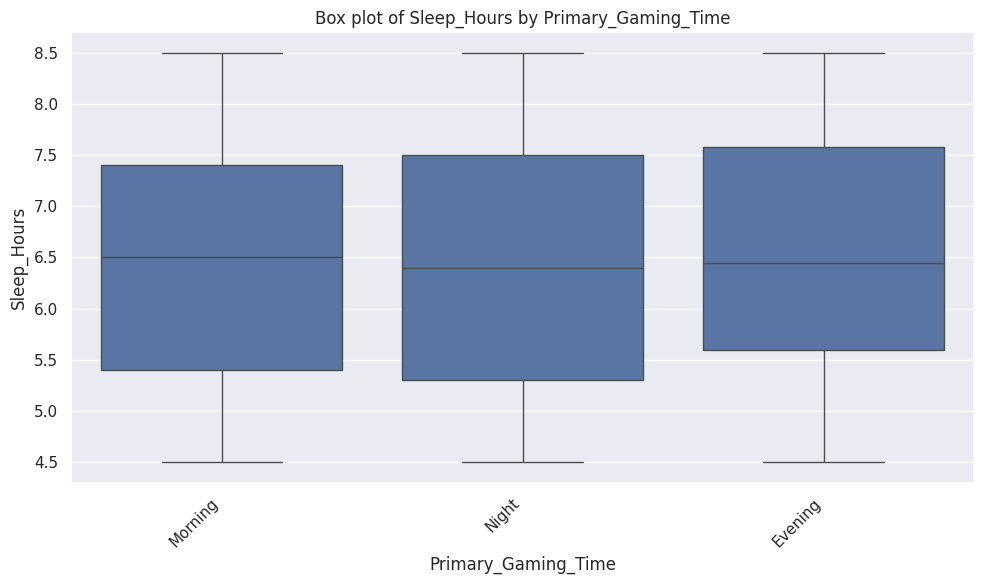

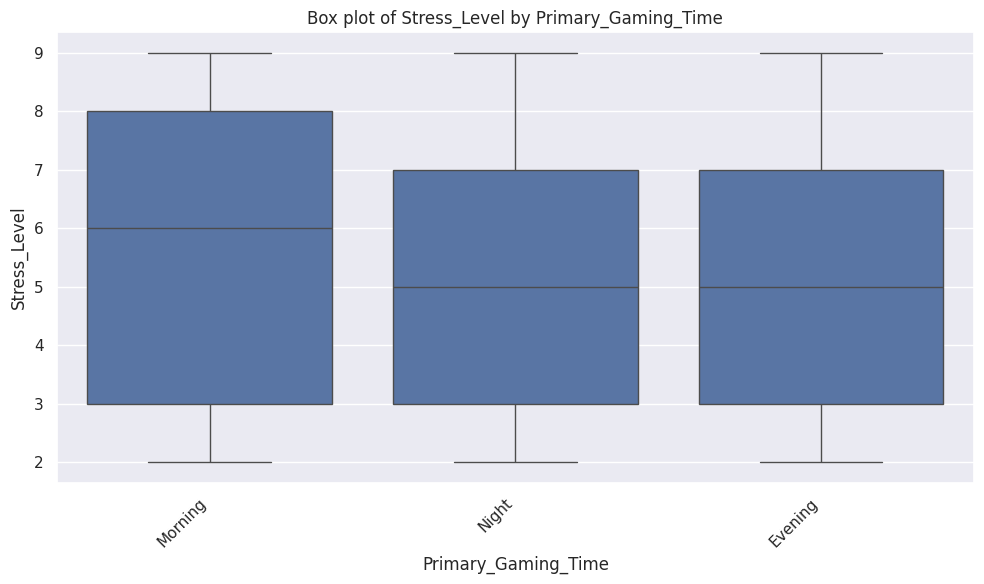

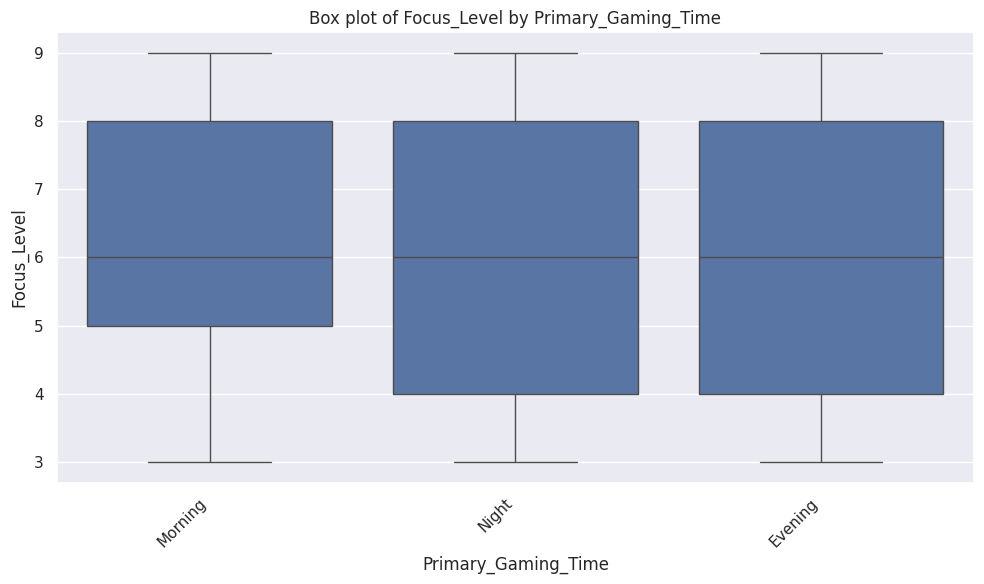

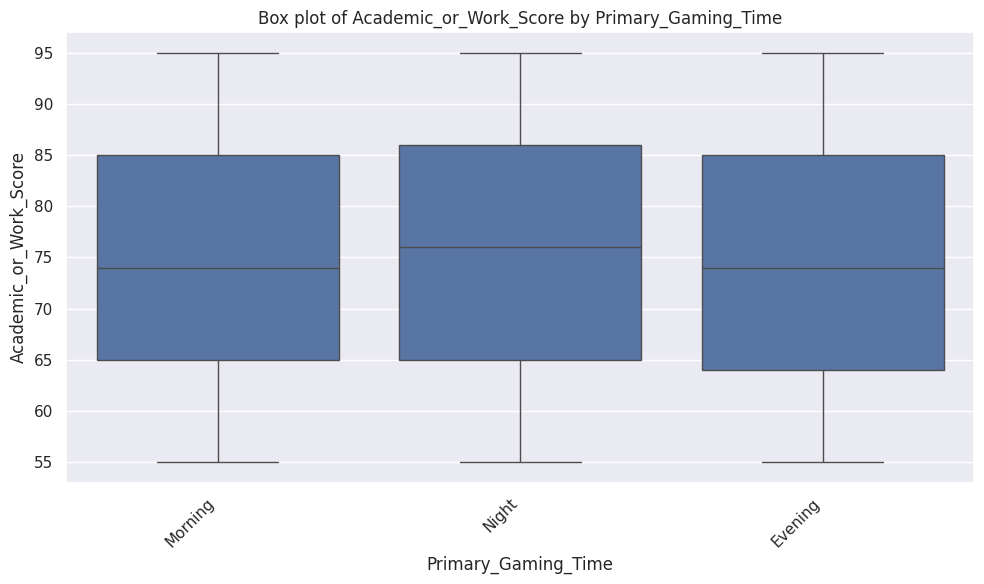

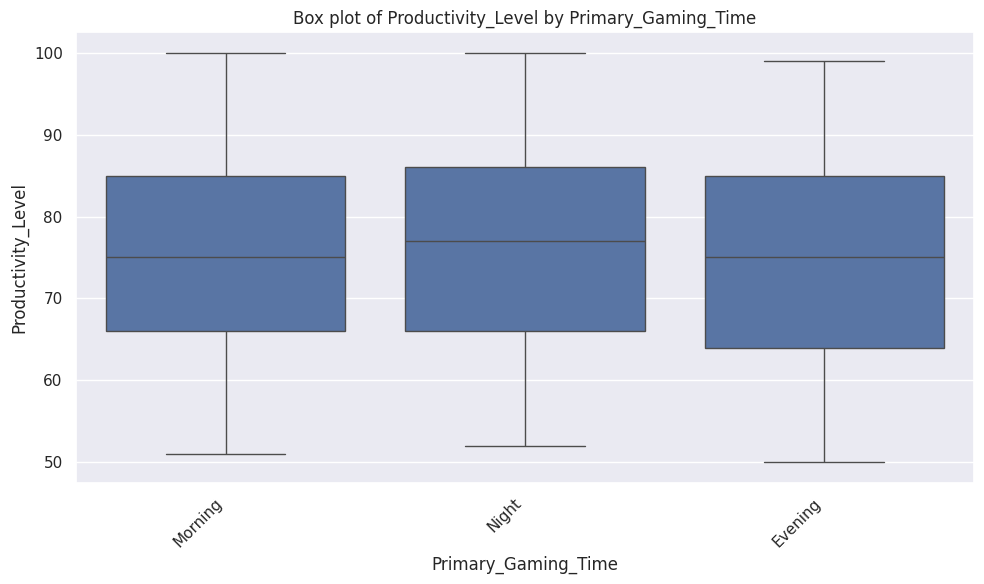

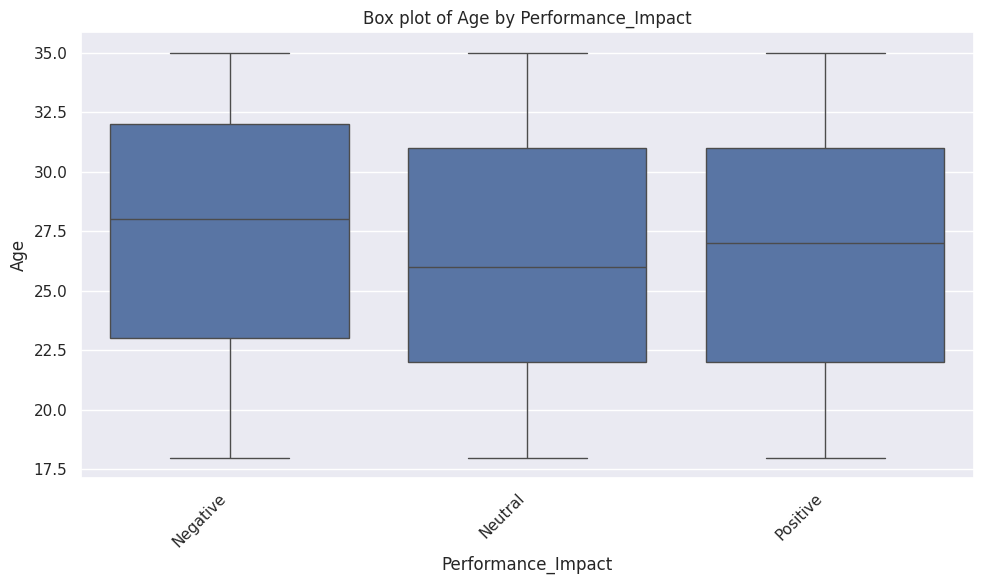

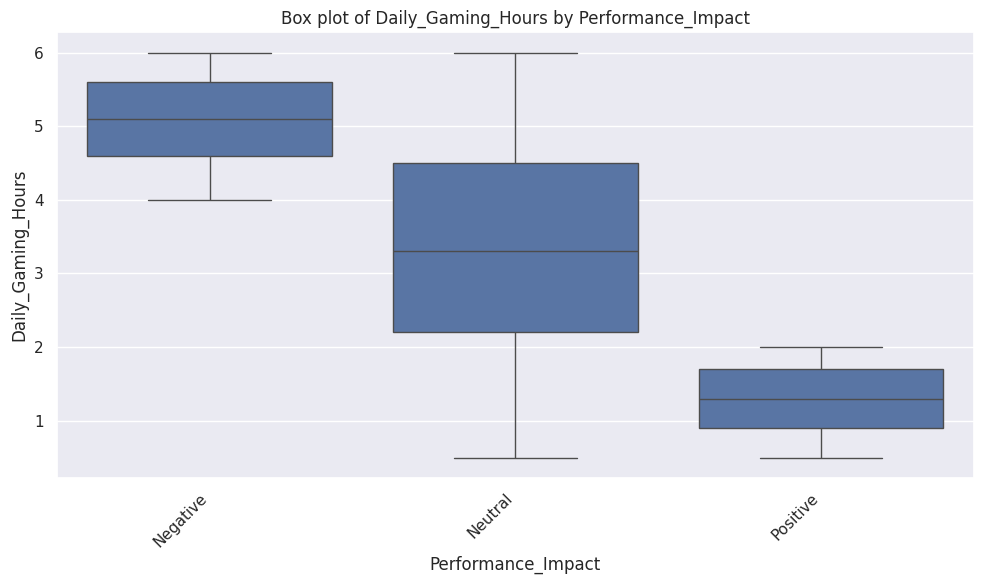

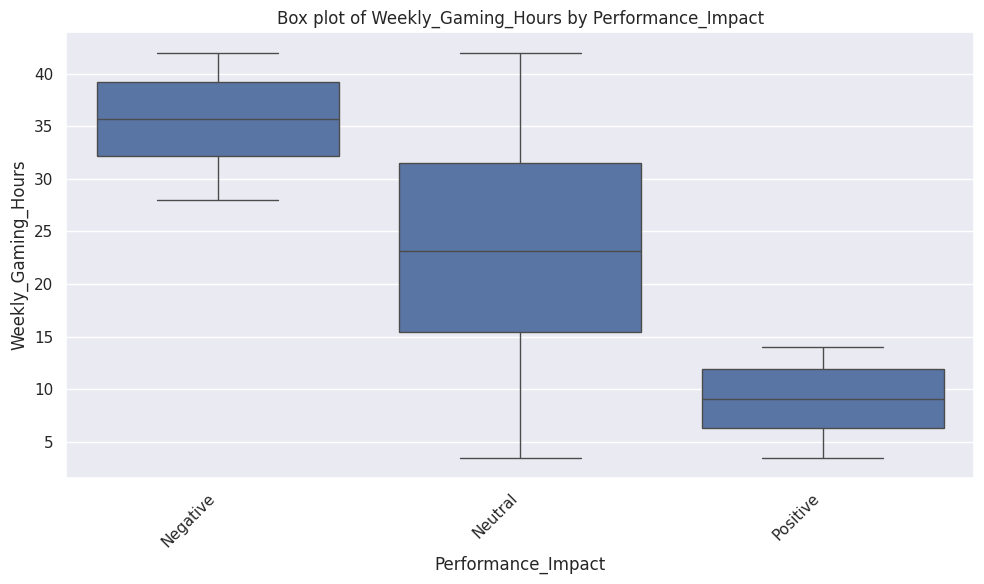

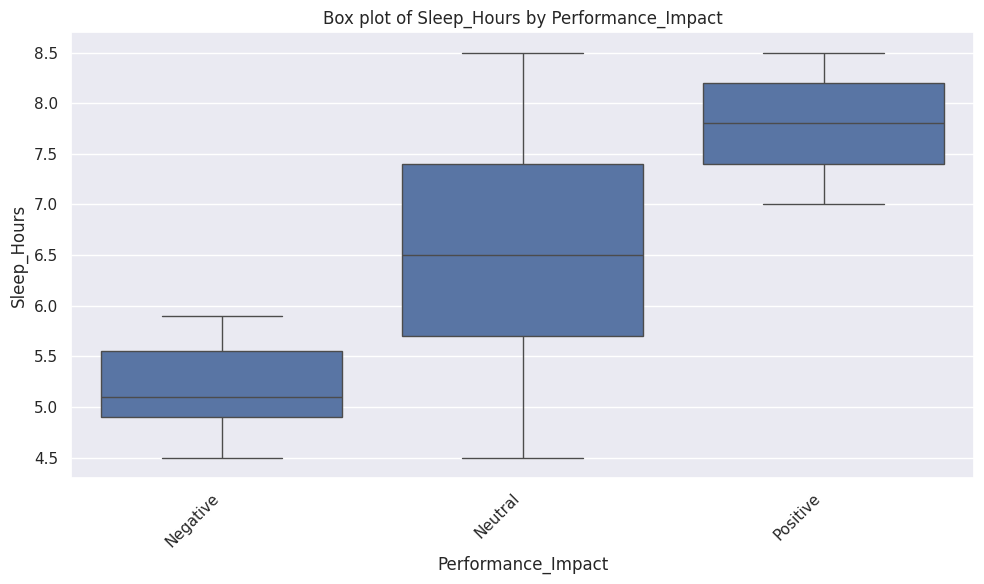

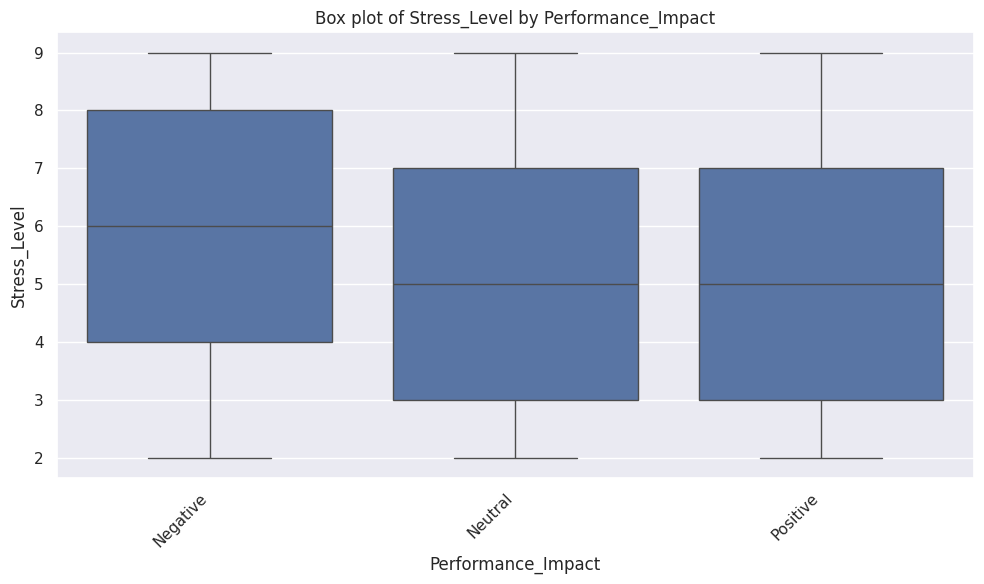

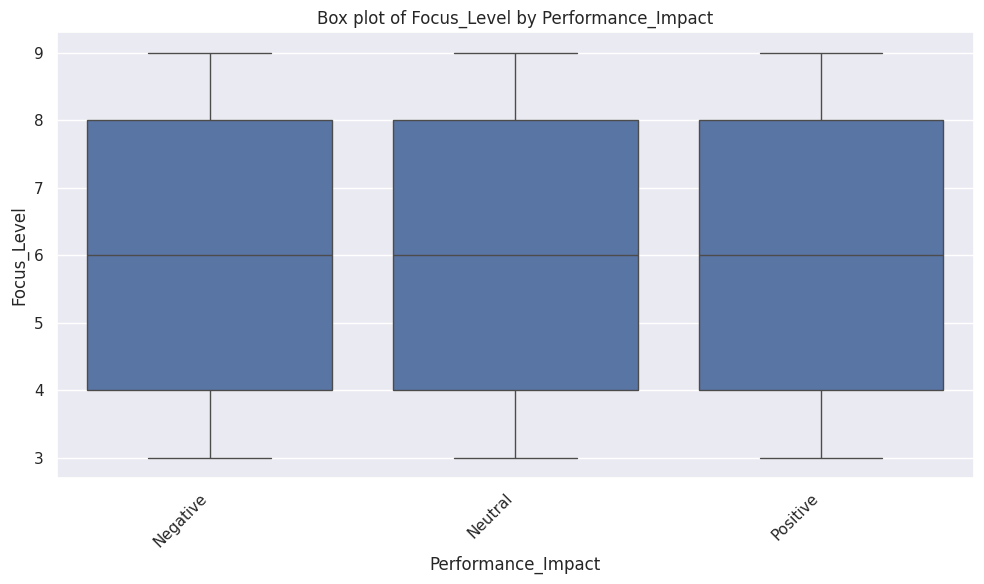

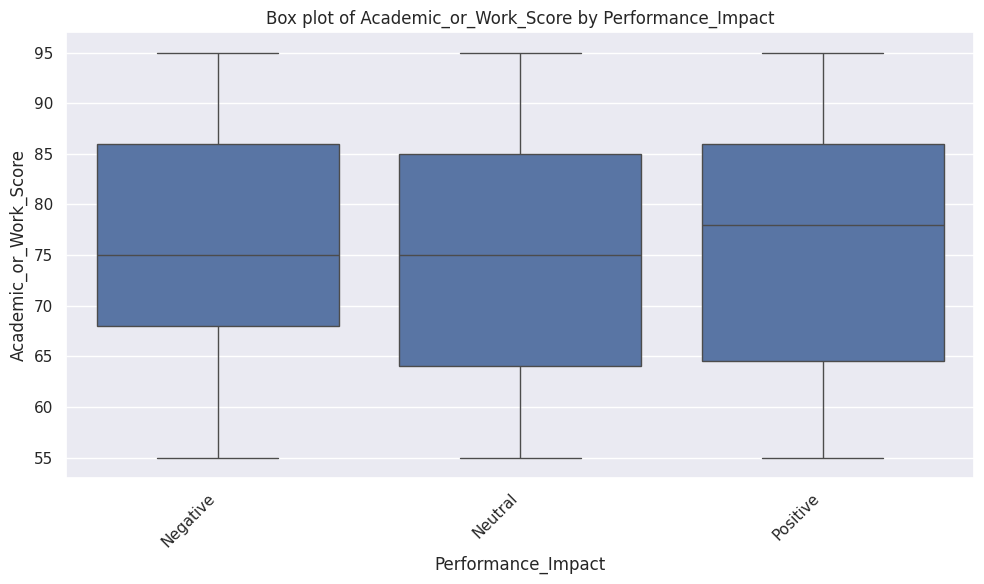

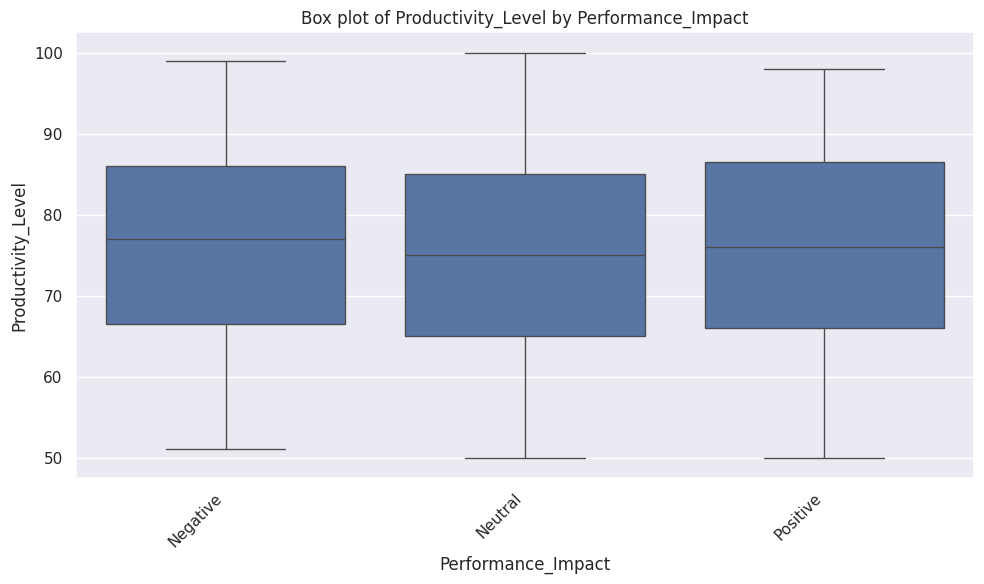

In [ ]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Exclude high-cardinality columns that are not suitable for box plots
cols_to_exclude_from_boxplot = ['title', 'original_title', 'overview', 'premiere_date']
filtered_categorical_cols = [col for col in categorical_cols if col not in cols_to_exclude_from_boxplot]

# Iterate through filtered categorical and numerical columns and create box plots
for cat_col in filtered_categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

# Pair-Plot

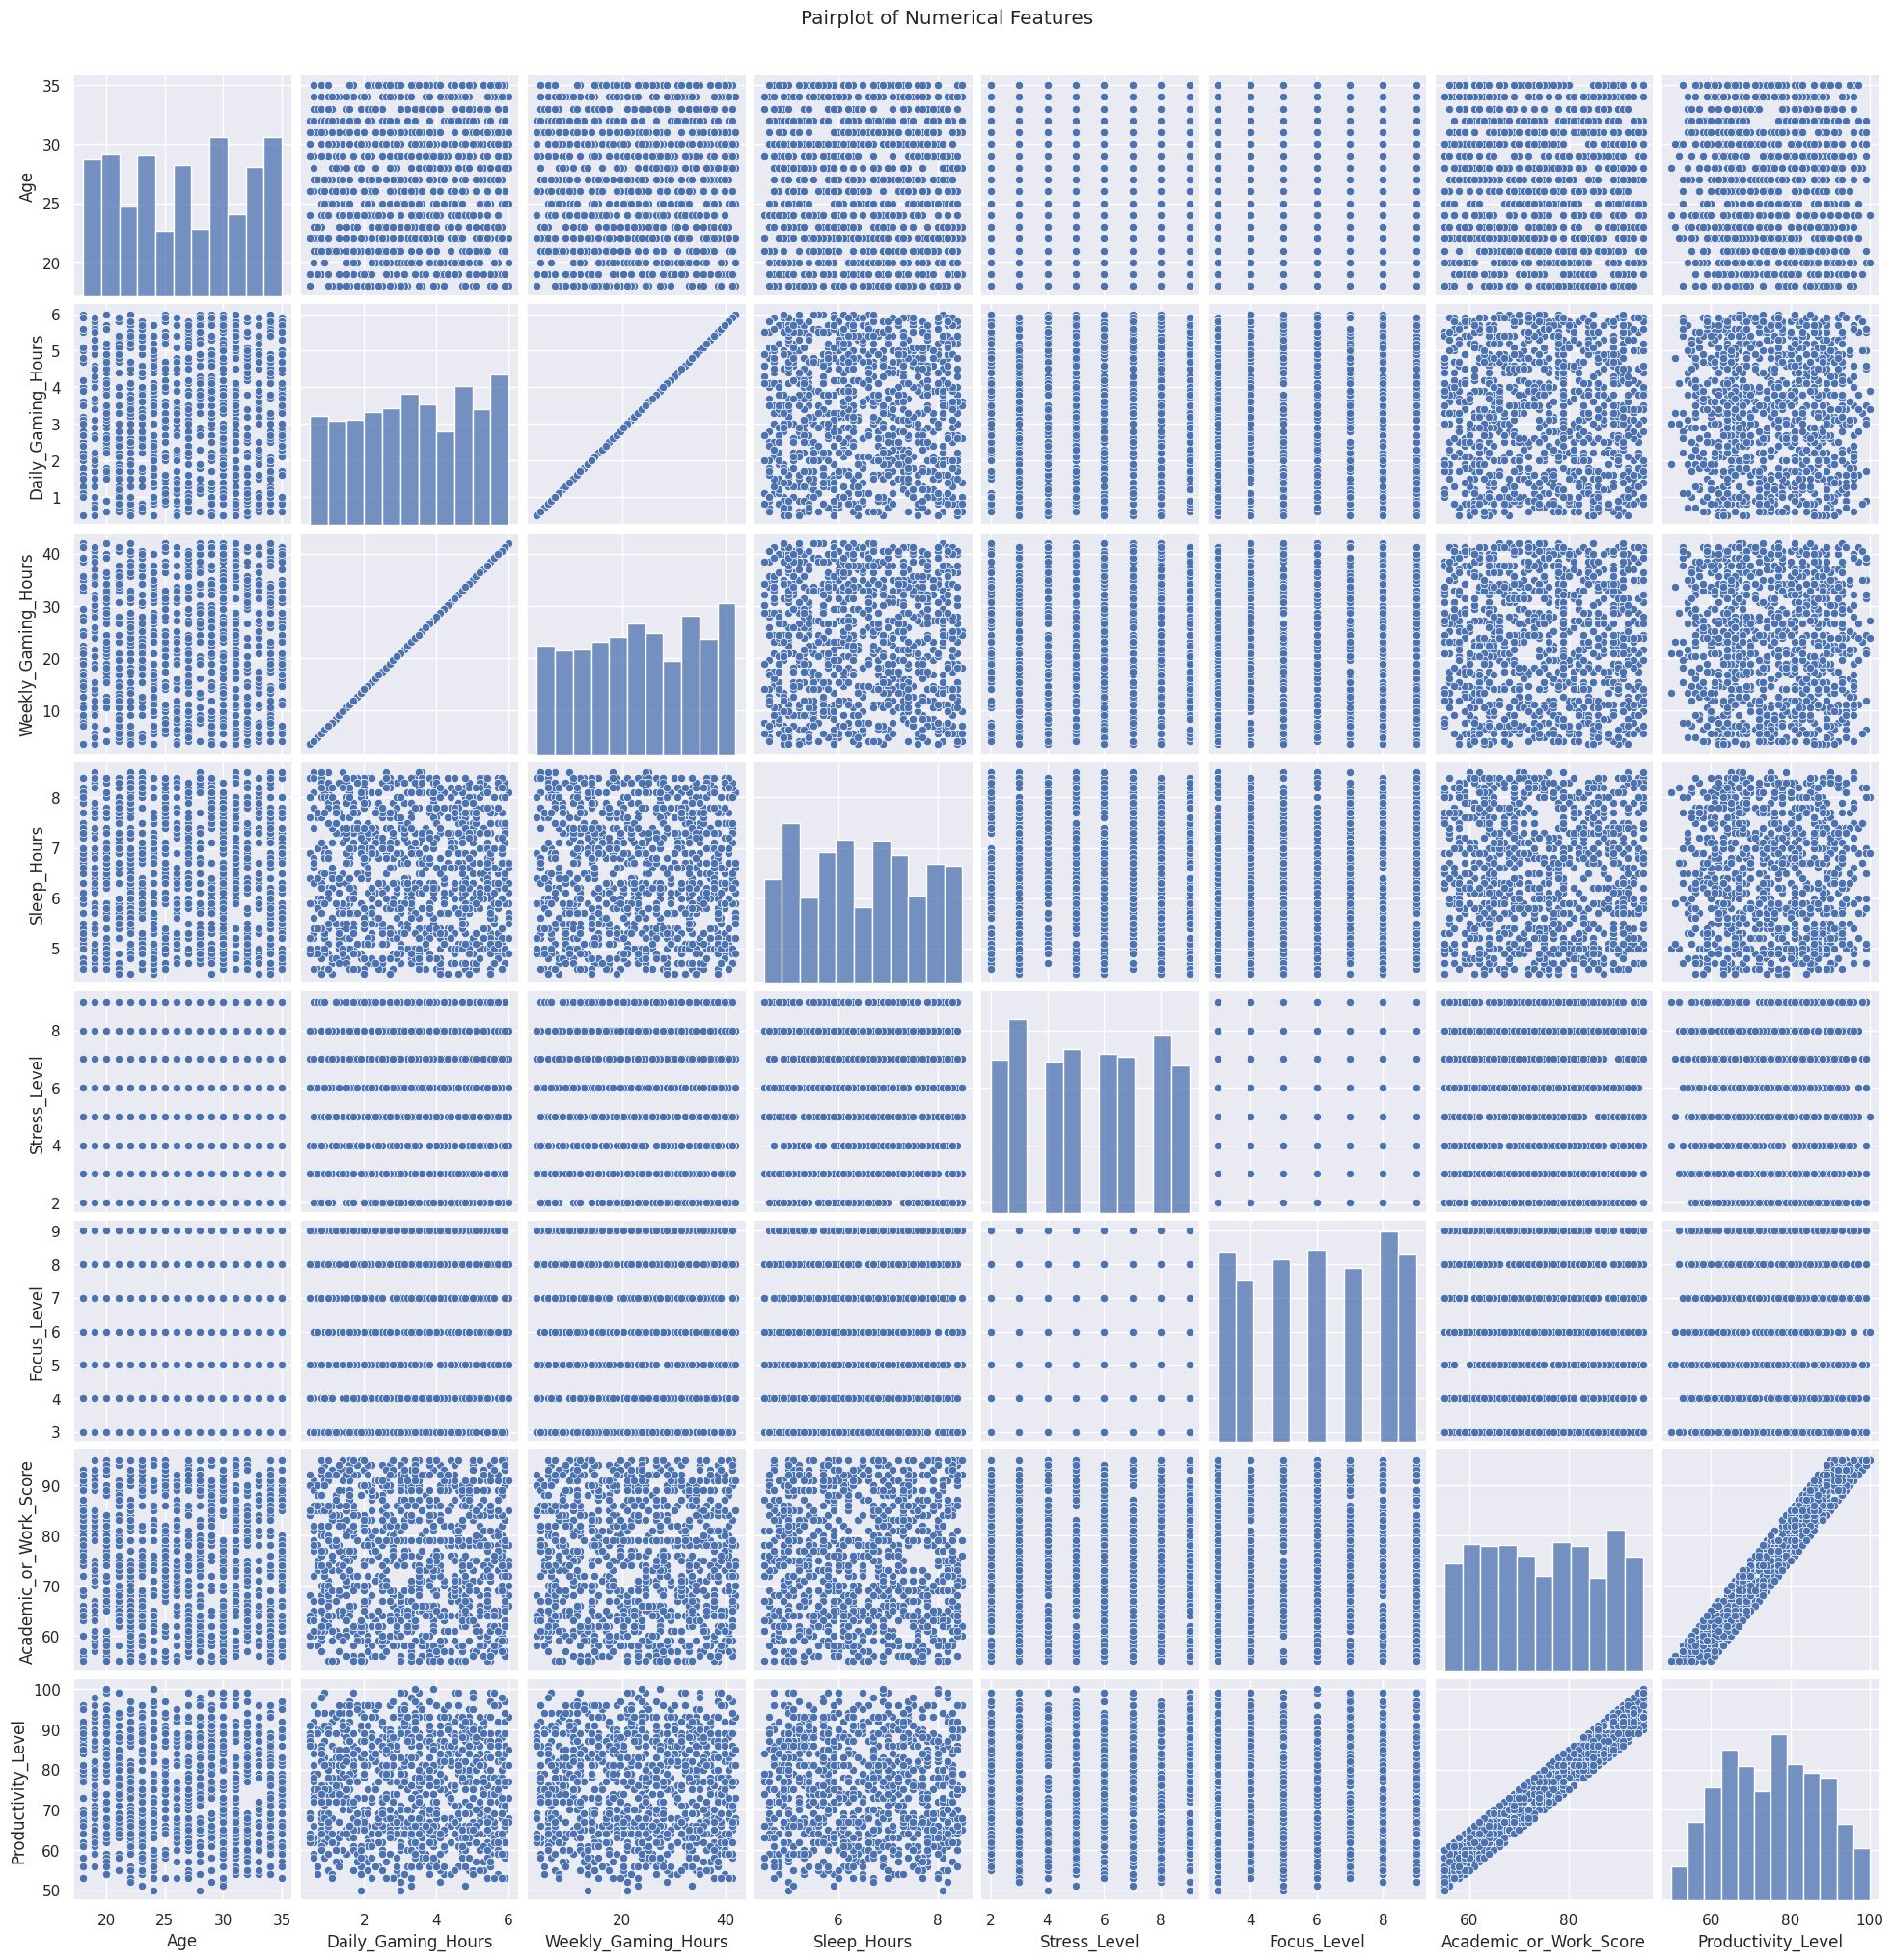

In [ ]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

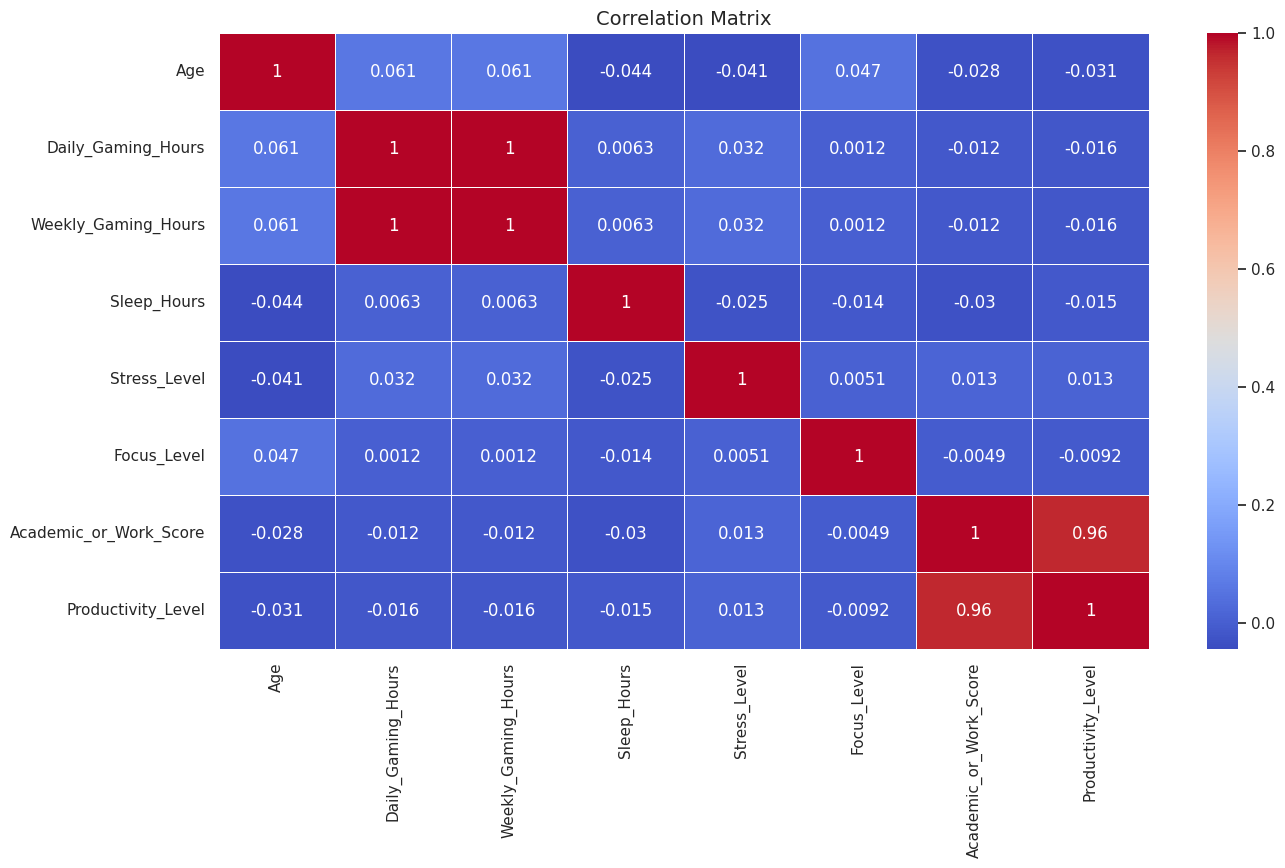

In [ ]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank You